In [ ]:
# !pip install omegaconf mlflow tqdm einops -q


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# !pip install pytorch-lightning


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
%matplotlib inline
import matplotlib.pyplot as plt


In [21]:
train_flag = False

In [5]:
import os
import torch
def setup_device(gpu_id: int = 0) -> torch.device:
    os.environ.pop("CUDA_VISIBLE_DEVICES", None)
    if torch.cuda.is_available():
        device = torch.device(f"cuda:{gpu_id}")
        torch.backends.cudnn.benchmark = True
        props = torch.cuda.get_device_properties(gpu_id)
        print(f"{'='*60}")
        print(f"🚀 GPU: {torch.cuda.get_device_name(gpu_id)}")
        print(f"   VRAM: {props.total_memory / 1e9:.1f} GB")
        print(f"   CUDA: {torch.version.cuda} | Torch: {torch.__version__}")
        print(f"{'='*60}\n")
    else:
        device = torch.device("cpu")
        print(f"{'='*60}")
        print("⚠️  GPU недоступен — используем CPU")
        print(f"{'='*60}\n")
    return device


## Config

In [5]:
# Cell 1 — Config (change only here)
from omegaconf import OmegaConf

cfg = OmegaConf.create({
    "data": {
        "sphar_root":    "SPHAR-Dataset-1.0(1)/SPHAR-Dataset-1.0/videos",      # папка с датасетом
        "skeleton_root": "data/skeletons",  # куда сохраняем скелеты
        "num_frames":    64,                # T — длина клипа
        "num_joints":    17,                # COCO keypoints
        "img_size":      640,
        "conf_thresh":   0.35,              # минимальная уверенность YoloPose
        "iou_thresh":    0.45,
        "skip_existing": True,              # пропускать уже обработанные видео
    },
    "model": {
        "in_channels":   2,    # (x, y)
        "num_classes":   14,   # классов в SPHAR
        "dropout":       0.3,
        "hidden_dim":    256,
    },
    "train": {
        "batch_size":    16,
        "lr":            1e-3,
        "weight_decay":  1e-4,
        "max_epochs":    60,
        "val_split":     0.2,
        "num_workers":   0,
        "seed":          42,
        "ckpt_dir":      "checkpoints/stage1_surveillance",
        "log_dir":       "mlruns",
    }
})

# Классы SPHAR (13 классов из датасета)
SPHAR_CLASSES = [
    "falling", "hitting", "igniting",
    "kicking", "luggage", "murdering",
    "neutral", "panicking", "running",
    "sitting", "stealing", "vandalizing",
    "walking"
]

print(OmegaConf.to_yaml(cfg))


data:
  sphar_root: SPHAR-Dataset-1.0(1)/SPHAR-Dataset-1.0/videos
  skeleton_root: data/skeletons
  num_frames: 64
  num_joints: 17
  img_size: 640
  conf_thresh: 0.35
  iou_thresh: 0.45
  skip_existing: true
model:
  in_channels: 2
  num_classes: 14
  dropout: 0.3
  hidden_dim: 256
train:
  batch_size: 16
  lr: 0.001
  weight_decay: 0.0001
  max_epochs: 60
  val_split: 0.2
  num_workers: 0
  seed: 42
  ckpt_dir: checkpoints/stage1_surveillance
  log_dir: mlruns



In [6]:
from pathlib import Path
from collections import defaultdict

sphar_root = Path(cfg.data.sphar_root)

print(f"Путь: {sphar_root.resolve()}")
print(f"Существует: {sphar_root.exists()}")
print()

if not sphar_root.exists():
    print("⚠ Папка не найдена! Проверьте cfg.data.sphar_root")
else:
    stats = defaultdict(int)
    all_videos = []

    for class_dir in sorted(sphar_root.iterdir()):
        if not class_dir.is_dir():
            continue
        videos = []
        for ext in ("*.avi", "*.mp4", "*.mov"):
            videos += list(class_dir.glob(ext))
        stats[class_dir.name] = len(videos)
        for v in videos:
            all_videos.append((v, class_dir.name))

    print(f"Всего видео: {len(all_videos)}")
    print(f"Классов найдено: {len(stats)}")
    print()

    # проверяем, все ли классы из конфига нашлись
    print(f"{'Класс':<15} {'Видео':>6}  {'В конфиге':>10}")
    print("-" * 36)
    for cls in sorted(stats.keys()):
        in_cfg = "✅" if cls in SPHAR_CLASSES else "❌ нет в конфиге"
        print(f"  {cls:<15} {stats[cls]:>4}    {in_cfg}")

    # классы из конфига, которых нет в папке
    missing = [c for c in SPHAR_CLASSES if c not in stats]
    if missing:
        print(f"\n⚠ Есть в конфиге, но нет папки: {missing}")
    else:
        print(f"\n✅ Все {len(SPHAR_CLASSES)} классов из конфига найдены в датасете")


Путь: C:\diplommaga\dataset\handlerntu\fine_tuning\SPHAR-Dataset-1.0(1)\SPHAR-Dataset-1.0\videos
Существует: True

Всего видео: 7587
Классов найдено: 13

Класс            Видео   В конфиге
------------------------------------
  falling          123    ✅
  hitting          401    ✅
  igniting         101    ✅
  kicking          120    ✅
  luggage            8    ✅
  murdering         52    ✅
  neutral         2166    ✅
  panicking         52    ✅
  running          516    ✅
  sitting          621    ✅
  stealing         418    ✅
  vandalizing      209    ✅
  walking         2800    ✅

✅ Все 13 классов из конфига найдены в датасете


## Проверка yolo выгрузки

In [7]:
import cv2
import numpy as np
import torch
from ultralytics import YOLO

yolo = YOLO("yolov8n-pose.pt")
device = "cuda" if torch.cuda.is_available() else "cpu"
yolo.to(device)
print(f"Устройство: {device}")


Устройство: cuda


In [8]:
import cv2
import numpy as np
import torch
from ultralytics import YOLO

# загрузка модели
model = YOLO("yolov8n-pose.pt")
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
print(f"Устройство: {device}")

# берём первое видео из датасета
test_video, test_class = all_videos[2]
print(f"Видео: {test_video.name}")
print(f"Класс: {test_class}")

# читаем средний кадр
cap = cv2.VideoCapture(str(test_video))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.set(cv2.CAP_PROP_POS_FRAMES, total_frames // 2)
ret, frame = cap.read()
cap.release()

print(f"Кадров в видео: {total_frames}")
print(f"Размер кадра:   {frame.shape}  (H, W, C)")

# запускаем YoloPose
results = model(frame, conf=cfg.data.conf_thresh, verbose=False)
kps_data = results[0].keypoints

print(f"\nНайдено людей: {len(kps_data.xy) if kps_data else 0}")

if kps_data is not None and len(kps_data.xy) > 0:
    kp = kps_data.xy[0].cpu().numpy()    # (17, 2)
    cf = kps_data.conf[0].cpu().numpy()  # (17,)
    good = (cf > cfg.data.conf_thresh).sum()
    print(f"Суставов с conf > {cfg.data.conf_thresh}: {good}/17")
    print(f"\nВсе суставы (x, y, conf):")
    for i, name in enumerate(["nose","left_eye","right_eye","left_ear","right_ear",
                               "left_shoulder","right_shoulder","left_elbow","right_elbow",
                               "left_wrist","right_wrist","left_hip","right_hip",
                               "left_knee","right_knee","left_ankle","right_ankle"]):
        marker = "✅" if cf[i] > cfg.data.conf_thresh else "❌"
        print(f"  {marker} [{i:2d}] {name:<16} x={kp[i,0]:6.1f}  y={kp[i,1]:6.1f}  conf={cf[i]:.2f}")
else:
    print("Человек не найден — снизьте cfg.data.conf_thres")


Устройство: cuda
Видео: casia_angleview_p08_faint_a1.mp4
Класс: falling
Кадров в видео: 266
Размер кадра:   (240, 320, 3)  (H, W, C)

Найдено людей: 1
Суставов с conf > 0.35: 17/17

Все суставы (x, y, conf):
  ✅ [ 0] nose             x=  93.9  y=  98.3  conf=0.85
  ✅ [ 1] left_eye         x=  94.6  y=  97.4  conf=0.75
  ✅ [ 2] right_eye        x=  93.1  y=  97.4  conf=0.74
  ✅ [ 3] left_ear         x=  95.8  y=  97.9  conf=0.57
  ✅ [ 4] right_ear        x=  91.9  y=  97.8  conf=0.53
  ✅ [ 5] left_shoulder    x=  98.1  y= 103.6  conf=0.98
  ✅ [ 6] right_shoulder   x=  89.9  y= 103.5  conf=0.99
  ✅ [ 7] left_elbow       x= 100.4  y= 111.3  conf=0.91
  ✅ [ 8] right_elbow      x=  88.8  y= 111.3  conf=0.92
  ✅ [ 9] left_wrist       x= 100.9  y= 118.4  conf=0.86
  ✅ [10] right_wrist      x=  88.5  y= 118.4  conf=0.86
  ✅ [11] left_hip         x=  96.9  y= 118.0  conf=0.99
  ✅ [12] right_hip        x=  91.3  y= 118.0  conf=0.99
  ✅ [13] left_knee        x=  98.4  y= 129.2  conf=0.97
  ✅ [14]

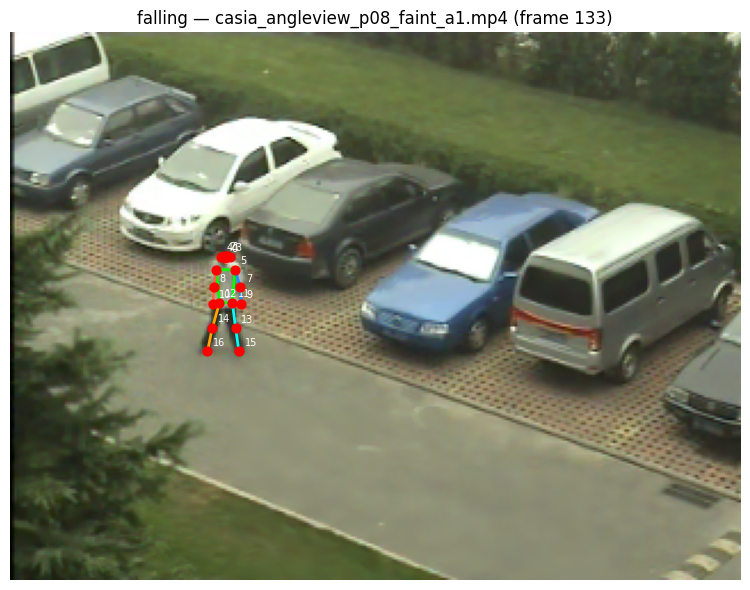

In [9]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# ── цвета костей (RGB для matplotlib) ───────────────────────────────
SKELETON_EDGES = [
    (0, 1,  "gold"),       # голова
    (0, 2,  "gold"),
    (1, 3,  "gold"),
    (2, 4,  "gold"),
    (5, 6,  "lime"),       # торс
    (5, 11, "lime"),
    (6, 12, "lime"),
    (11,12, "lime"),
    (5, 7,  "dodgerblue"), # левая рука
    (7, 9,  "dodgerblue"),
    (6, 8,  "tomato"),     # правая рука
    (8, 10, "tomato"),
    (11,13, "cyan"),       # левая нога
    (13,15, "cyan"),
    (12,14, "orange"),     # правая нога
    (14,16, "orange"),
]

KPT_NAMES = [
    "nose","left_eye","right_eye","left_ear","right_ear",
    "left_shoulder","right_shoulder","left_elbow","right_elbow",
    "left_wrist","right_wrist","left_hip","right_hip",
    "left_knee","right_knee","left_ankle","right_ankle"
]

def show_frame_with_skeleton(frame_bgr, kp, conf, conf_thresh=0.25, title=""):
    """
    frame_bgr : (H, W, 3) BGR кадр из OpenCV
    kp        : (17, 2)   пиксельные координаты
    conf      : (17,)     уверенность каждой точки
    """
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(frame_rgb)

    # кости
    for (a, b, color) in SKELETON_EDGES:
        if conf[a] >= conf_thresh and conf[b] >= conf_thresh:
            ax.plot(
                [kp[a, 0], kp[b, 0]],
                [kp[a, 1], kp[b, 1]],
                color=color, linewidth=2, solid_capstyle="round"
            )

    # суставы
    for i in range(17):
        if conf[i] >= conf_thresh:
            ax.scatter(kp[i, 0], kp[i, 1], c="red", s=40, zorder=5)
            ax.annotate(
                str(i),
                (kp[i, 0], kp[i, 1]),
                textcoords="offset points",
                xytext=(4, 4),
                fontsize=7,
                color="white",
            )

    ax.set_title(title)
    ax.axis("off")
    plt.tight_layout()
    plt.show()


# ── запуск на тестовом кадре ─────────────────────────────────────────
show_frame_with_skeleton(
    frame_bgr=frame,
    kp=kp,
    conf=cf,
    conf_thresh=cfg.data.conf_thresh,
    title=f"{test_class} — {test_video.name} (frame {total_frames // 2})"
)


# YOLO extract sphar

In [10]:
import cv2
import numpy as np
import torch
from pathlib import Path
from tqdm import tqdm

def extract_skeleton(video_path: Path, model, cfg) -> np.ndarray:
    """
    Читает видео, сэмплирует T кадров, запускает YoloPose.
    Возвращает (T, 17, 3) — (x, y, conf), координаты нормализованы в [0, 1].
    """
    T   = cfg.data.num_frames
    V   = cfg.data.num_joints

    cap = cv2.VideoCapture(str(video_path))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # равномерно выбираем T кадров
    indices = set(np.linspace(0, max(total - 1, 0), T, dtype=int).tolist())

    frames_kp  = []
    frame_idx  = 0

    while cap.isOpened() and len(frames_kp) < T:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_idx in indices:
            H, W = frame.shape[:2]
            results = model(frame, conf=cfg.data.conf_thresh,
                            iou=cfg.data.iou_thresh, verbose=False)
            kps = results[0].keypoints

            if kps is not None and len(kps.xy) > 0:
                # выбираем персону с наибольшей суммарной уверенностью
                best = kps.conf.sum(dim=1).argmax().item()
                xy   = kps.xy[best].cpu().numpy()    # (17, 2) пиксели
                cf   = kps.conf[best].cpu().numpy()  # (17,)

                # нормализуем координаты в [0, 1]
                xy[:, 0] /= W
                xy[:, 1] /= H
            else:
                xy = np.zeros((V, 2), dtype=np.float32)
                cf = np.zeros(V,      dtype=np.float32)

            kp_frame = np.concatenate([xy, cf[:, None]], axis=1)  # (17, 3)
            frames_kp.append(kp_frame)

        frame_idx += 1

    cap.release()

    # если видео короче T — паддинг последним кадром
    if len(frames_kp) == 0:
        frames_kp = [np.zeros((V, 3), dtype=np.float32)]
    while len(frames_kp) < T:
        frames_kp.append(frames_kp[-1].copy())

    return np.stack(frames_kp[:T], axis=0).astype(np.float32)  # (T, 17, 3)


# ── параметры ────────────────────────────────────────────────────────
skeleton_root = Path(cfg.data.skeleton_root)
skeleton_root.mkdir(parents=True, exist_ok=True)

failed  = []
skipped = 0
done    = 0

# (удалён `return`, он не разрешён в глобальной области)
if train_flag:
    print(f"Всего видео: {len(all_videos)}")
    print(f"Сохраняем в: {skeleton_root.resolve()}")
    print(f"skip_existing: {cfg.data.skip_existing}\n")

    # ── основной цикл ────────────────────────────────────────────────────
    for i, (video_path, class_name) in enumerate(tqdm(all_videos, desc="Extracting")):

        out_dir  = skeleton_root / class_name
        out_dir.mkdir(parents=True, exist_ok=True)
        out_file = out_dir / (video_path.stem + ".npz")

        # пропускаем уже обработанные
        if cfg.data.skip_existing and out_file.exists():
            skipped += 1
            continue

        try:
            skeleton = extract_skeleton(video_path, model, cfg)  # (T, 17, 3)

            np.savez_compressed(
                out_file,
                skeleton   = skeleton,          # (T, 17, 3) — x, y, conf
                class_name = class_name,
                video      = video_path.stem,
            )
            done += 1

        except Exception as e:
            failed.append((video_path.name, str(e)))

        # прогресс каждые 20 видео
        if (i + 1) % 20 == 0:
            print(f"  [{i+1}/{len(all_videos)}] done={done} skipped={skipped} failed={len(failed)}")

    # ── итог ─────────────────────────────────────────────────────────────
    print(f"\n{'='*40}")
    print(f"✅ Готово:    {done}")
    print(f"⏭ Пропущено: {skipped}")
    print(f"❌ Ошибки:    {len(failed)}")
    if failed:
        print("\nПроблемные файлы:")
        for name, err in failed:
            print(f"  {name}: {err}")


NameError: name 'train_flag' is not defined

In [11]:
# Диагностика — запускаем на одном файле и смотрим ошибку
test_video, test_class = all_videos[0]
print(f"Видео: {test_video}")

try:
    skeleton = extract_skeleton(test_video, model, cfg)
    print(f"✅ OK — shape: {skeleton.shape}")
except Exception as e:
    import traceback
    traceback.print_exc()


Видео: SPHAR-Dataset-1.0(1)\SPHAR-Dataset-1.0\videos\falling\casia_angleview_p01_faint_a1.mp4
✅ OK — shape: (64, 17, 3)


In [12]:
# проверка — смотрим что сохранилось
total_saved = list(skeleton_root.rglob("*.npz"))
print(f"Всего сохранено .npz: {len(total_saved)}")

# по классам
from collections import Counter
by_class = Counter(p.parent.name for p in total_saved)
for cls, cnt in sorted(by_class.items()):
    print(f"  {cls:<15} {cnt:>4}")


Всего сохранено .npz: 7587
  falling          123
  hitting          401
  igniting         101
  kicking          120
  luggage            8
  murdering         52
  neutral         2166
  panicking         52
  running          516
  sitting          621
  stealing         418
  vandalizing      209
  walking         2800


# перевыгрузка плохих файлов

In [ ]:
import numpy as np
from pathlib import Path
from tqdm import tqdm

if False:
    skeleton_root = Path(cfg.data.skeleton_root)
    BAD_THRESHOLD = 0.5   # файл считается плохим если >50% кадров пусто

    # находим плохие файлы
    bad_files = []
    for path in skeleton_root.rglob("*.npz"):
        data  = np.load(path, allow_pickle=True)
        seq   = data["skeleton"][:, :, :2]   # (T, 17, 2)
        empty = (np.abs(seq).sum(axis=(1,2)) < 1e-4).mean()
        if empty > BAD_THRESHOLD:
            bad_files.append(path)

    print(f"Файлов для перевыгрузки: {len(bad_files)}")


Файлов для перевыгрузки: 3871


In [ ]:
# # временно меняем conf_thresh только для перевыгрузки
# from omegaconf import OmegaConf

# cfg_reextract = OmegaConf.merge(cfg, OmegaConf.create({
#     "data": {
#         "conf_thresh":   0.15,
#         "img_size":      1280,
#         "skip_existing": False,  # перезаписываем
#     }
# }))

# failed_reextract = []
# done_reextract   = 0

# for npz_path in tqdm(bad_files, desc="Re-extracting"):
#     class_name = npz_path.parent.name

#     # ищем оригинальное видео
#     video_stem = str(np.load(npz_path, allow_pickle=True)["video"])
#     video_path = None
#     for ext in (".mp4", ".avi", ".mov"):
#         candidate = Path(cfg.data.sphar_root) / class_name / (video_stem + ext)
#         if candidate.exists():
#             video_path = candidate
#             break

#     if video_path is None:
#         failed_reextract.append((npz_path.name, "видео не найдено"))
#         continue

#     try:
#         skeleton = extract_skeleton(video_path, yolo, cfg_reextract)
#         np.savez_compressed(
#             npz_path,          # перезаписываем тот же файл
#             skeleton   = skeleton,
#             class_name = class_name,
#             video      = video_stem,
#         )
#         done_reextract += 1
#     except Exception as e:
#         failed_reextract.append((npz_path.name, str(e)))

# print(f"\n✅ Перевыгружено: {done_reextract}")
# print(f"❌ Ошибок:        {len(failed_reextract)}")


Re-extracting: 100%|██████████| 4754/4754 [1:05:28<00:00,  1.21it/s]


✅ Перевыгружено: 4754
❌ Ошибок:        0


In [ ]:
# import numpy as np
# from pathlib import Path
# from collections import defaultdict

# skeleton_root = Path(cfg.data.skeleton_root)
# all_npz = list(skeleton_root.rglob("*.npz"))

# stats = {
#     "total":          0,
#     "all_zero":       0,   # скелет полностью нулевой
#     "mostly_zero":    0,   # >50% кадров нулевые
#     "short":          0,   # кадров меньше чем num_frames
#     "good":           0,
# }

# zero_ratio_by_class = defaultdict(list)

# for path in all_npz:
#     data    = np.load(path, allow_pickle=True)
#     seq     = data["skeleton"]        # (T, 17, 3)
#     cls     = path.parent.name

#     T = seq.shape[0]
#     xy = seq[:, :, :2]                # (T, 17, 2)

#     # кадр «нулевой» если все суставы ≈ 0
#     frame_has_person = (np.abs(xy).sum(axis=(1, 2)) > 1e-4)  # (T,)
#     zero_ratio = 1.0 - frame_has_person.mean()

#     zero_ratio_by_class[cls].append(zero_ratio)
#     stats["total"] += 1

#     if zero_ratio == 1.0:
#         stats["all_zero"] += 1
#     elif zero_ratio > 0.5:
#         stats["mostly_zero"] += 1
#     elif T < cfg.data.num_frames:
#         stats["short"] += 1
#     else:
#         stats["good"] += 1

# print("="*50)
# print(f"Всего файлов:          {stats['total']}")
# print(f"✅ Хороших:            {stats['good']}")
# print(f"⚠ >50% кадров пусто:  {stats['mostly_zero']}")
# print(f"❌ Полностью пустых:   {stats['all_zero']}")
# print(f"❌ Коротких (<{cfg.data.num_frames} кадров): {stats['short']}")

# print("\nСредний % пустых кадров по классам:")
# print(f"{'Класс':<15} {'Пустых кадров %':>15}  {'Файлов':>8}")
# print("-"*42)
# for cls in sorted(zero_ratio_by_class.keys()):
#     ratios = zero_ratio_by_class[cls]
#     mean_zero = np.mean(ratios) * 100
#     print(f"  {cls:<15} {mean_zero:>13.1f}%  {len(ratios):>8}")


Всего файлов:          7587
✅ Хороших:            3716
⚠ >50% кадров пусто:  2591
❌ Полностью пустых:   1280
❌ Коротких (<64 кадров): 0

Средний % пустых кадров по классам:
Класс           Пустых кадров %    Файлов
------------------------------------------
  falling                  56.1%       123
  hitting                  38.4%       401
  igniting                 62.0%       101
  kicking                  15.5%       120
  luggage                  42.2%         8
  murdering                44.4%        52
  neutral                  45.4%      2166
  panicking                81.5%        52
  running                  71.4%       516
  sitting                  48.5%       621
  stealing                 41.5%       418
  vandalizing              71.8%       209
  walking                  59.1%      2800


Файл:         data\skeletons\walking\virat_VIRAT_S_040104_04_000854_000934_carrying_22.npz
Пустых кадров: 93.8%
Видео:        SPHAR-Dataset-1.0(1)\SPHAR-Dataset-1.0\videos\walking\virat_VIRAT_S_040104_04_000854_000934_carrying_22.mp4
Кадров:       481
Размер:       (216, 140, 3)

С conf=0.01:
  Найдено боксов:   0
  Найдено скелетов: 0


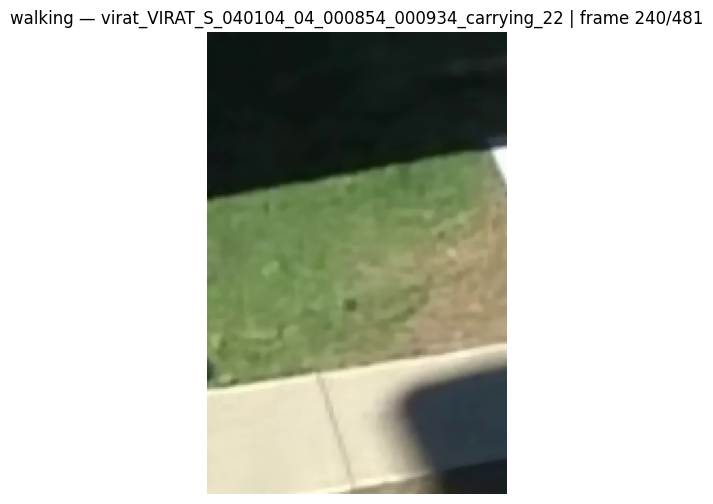

In [ ]:
# import numpy as np
# import cv2
# from pathlib import Path

# # берём один из плохих файлов
# bad_files_list = []
# for path in Path(cfg.data.skeleton_root).rglob("*.npz"):
#     data  = np.load(path, allow_pickle=True)
#     seq   = data["skeleton"][:, :, :2]
#     empty = (np.abs(seq).sum(axis=(1,2)) < 1e-4).mean()
#     if empty > 0.5:
#         bad_files_list.append((path, empty))

# # сортируем по проценту пустых — берём средний (не самый плохой)
# bad_files_list.sort(key=lambda x: x[1])
# mid = len(bad_files_list) // 2
# bad_npz, empty_ratio = bad_files_list[mid]

# print(f"Файл:         {bad_npz}")
# print(f"Пустых кадров: {empty_ratio*100:.1f}%")

# # находим оригинальное видео
# video_stem = str(np.load(bad_npz, allow_pickle=True)["video"])
# class_name = bad_npz.parent.name
# video_path = None
# for ext in (".mp4", ".avi", ".mov"):
#     c = Path(cfg.data.sphar_root) / class_name / (video_stem + ext)
#     if c.exists():
#         video_path = c
#         break

# print(f"Видео:        {video_path}")

# # читаем средний кадр и смотрим что там
# cap = cv2.VideoCapture(str(video_path))
# total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
# cap.set(cv2.CAP_PROP_POS_FRAMES, total // 2)
# ret, frame = cap.read()
# cap.release()

# print(f"Кадров:       {total}")
# print(f"Размер:       {frame.shape}")

# # запускаем YoloPose с минимальным порогом
# import torch
# results = yolo(frame, conf=0.01, verbose=False)   # ← 0.01 минимум возможного
# kps = results[0].keypoints
# boxes = results[0].boxes

# print(f"\nС conf=0.01:")
# print(f"  Найдено боксов:   {len(boxes) if boxes else 0}")
# print(f"  Найдено скелетов: {len(kps.xy) if kps else 0}")

# if kps is not None and len(kps.xy) > 0:
#     cf = kps.conf[0].cpu().numpy()
#     print(f"  Уверенности суставов: min={cf.min():.3f} max={cf.max():.3f} mean={cf.mean():.3f}")

# # показываем кадр
# import matplotlib.pyplot as plt
# plt.figure(figsize=(10, 6))
# plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
# plt.title(f"{class_name} — {video_stem} | frame {total//2}/{total}")
# plt.axis("off")
# plt.show()


## Dataset DataModule

In [14]:

import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from pathlib import Path
from collections import Counter
import pytorch_lightning as pl


from torch.utils.data import Dataset
from pathlib import Path


class SPHARSkeletonDataset(Dataset):
    """
    PyTorch Dataset для скелетных последовательностей из SPHAR.

    Контракт PyTorch Dataset:
    ─────────────────────────
    __len__     — сколько сэмплов в датасете
    __getitem__ — вернуть один сэмпл по индексу

    Соглашения:
    ─────────────────────────
    - Dataset не должен хранить все данные в памяти сразу.
      Вместо этого он хранит список путей и читает файл только в __getitem__.
      Это стандартный паттерн для больших датасетов (lazy loading).

    - Аугментации принято делать внутри __getitem__, а не заранее.
      Так каждый раз при итерации по датасету сэмпл немного разный.

    - __getitem__ должен возвращать torch.Tensor, а не numpy.
      DataLoader ожидает тензоры для автоматической сборки батчей.

    Формат данных:
    ─────────────────────────
    Входной .npz:  skeleton (T, 17, 3) — x, y, conf
    Выход модели:  (C, T, V) = (2, 64, 17) — ST-GCN ожидает именно такой порядок осей
    """

    def __init__(
    self,
    skeleton_root: str,
    classes: list,
    augment: bool = False,
    num_frames: int = 64,
    conf_thresh: float = 0.25,
    min_valid_ratio: float = 0.3,   # ← минимум 30% кадров должны быть непустыми
    ):
        self.augment         = augment
        self.num_frames      = num_frames
        self.conf_thresh     = conf_thresh
        self.min_valid_ratio = min_valid_ratio
        self.class2idx       = {c: i for i, c in enumerate(classes)}
        self.samples         = []

        skipped_empty = 0

        for class_name in classes:
            class_dir = Path(skeleton_root) / class_name
            if not class_dir.exists():
                print(f"⚠ Папка не найдена: {class_dir}")
                continue

            for npz_path in sorted(class_dir.glob("*.npz")):
                # проверяем качество файла
                try:
                    data = np.load(npz_path, allow_pickle=True)
                    seq  = data["skeleton"][:, :, :2]   # (T, 17, 2)
                    valid_ratio = (
                        np.abs(seq).sum(axis=(1, 2)) > 1e-4
                    ).mean()

                    if valid_ratio < self.min_valid_ratio:
                        skipped_empty += 1
                        continue

                except Exception:
                    skipped_empty += 1
                    continue

                self.samples.append((npz_path, self.class2idx[class_name]))

        print(f"Dataset: {len(self.samples)} сэмплов, "
            f"{len(classes)} классов, "
            f"пропущено пустых: {skipped_empty}")

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int):
        path, label = self.samples[idx]

        # ── загрузка ──────────────────────────────────────────────────
        data = np.load(path, allow_pickle=True)
        if "skeleton" in data.files:
            seq = data["skeleton"].astype(np.float32)   # SPHAR формат
        elif "keypoints" in data.files:
            seq = data["keypoints"].astype(np.float32)  # Biisk формат
        else:
            raise KeyError(f"{path} не содержит 'skeleton' или 'keypoints'")

# ожидаем (T, 17, 3) — x,y,conf
        assert seq.ndim == 3 and seq.shape[1] == 17 and seq.shape[2] == 3, \
            f"Неожиданная форма {seq.shape} в {path}"

        # ── применяем порог уверенности ───────────────────────────────
        # суставы с низкой уверенностью YoloPose обнуляем
        # это лучше чем оставлять шумные координаты
        conf = seq[:, :, 2:]          # (T, 17, 1)
        xy   = seq[:, :, :2]          # (T, 17, 2)
        xy   = xy * (conf >= self.conf_thresh)  # обнуляем ненадёжные
        seq  = xy                     # (T, 17, 2) — conf больше не нужен

        # ── нормализация скелета ──────────────────────────────────────
        seq = self._normalize(seq)    # body-centric, инвариантна к расстоянию

        # ── аугментации (только на train) ────────────────────────────
        if self.augment:
            seq = self._augment(seq)

        # ── изменение осей для ST-GCN ─────────────────────────────────
        # ST-GCN ожидает (C, T, V):
        #   C = каналы (x, y = 2)
        #   T = временная ось (кадры)
        #   V = вершины графа (суставы)
        seq = seq.transpose(2, 0, 1)  # (T, 17, 2) → (2, T, 17)

        x = torch.from_numpy(seq.copy())
        y = torch.tensor(label, dtype=torch.long)
        return x, y

    # ── вспомогательные методы ────────────────────────────────────────

    def _normalize(self, seq: np.ndarray) -> np.ndarray:
        """
        Body-centric нормализация:
        1. Origin → hip center (среднее левого и правого бедра)
        2. Scale  → расстояние между плечами

        Зачем: убирает зависимость от позиции и расстояния до камеры.
        Скелет стоящего человека у стены и у камеры будет одинаковым.
        """
        # COCO: 11=left_hip, 12=right_hip
        hip_center = (seq[:, 11:12, :] + seq[:, 12:13, :]) / 2.0  # (T, 1, 2)
        seq = seq - hip_center

        # COCO: 5=left_shoulder, 6=right_shoulder
        shoulder_dist = np.linalg.norm(
            seq[:, 5, :] - seq[:, 6, :], axis=-1
        ).mean()  # скаляр

        # делим только если плечи реально видны
        if shoulder_dist > 1e-4:
            seq = seq / shoulder_dist

        return seq.astype(np.float32)

    def _augment(self, seq: np.ndarray) -> np.ndarray:
        """
        Лёгкие аугментации для surveillance скелетов.

        Зачем каждая:
        - temporal crop   — модель не должна зависеть от точного начала/конца действия
        - horizontal flip — действия симметричны, удваиваем датасет бесплатно
        - rotation        — имитирует разные углы камеры
        - joint noise     — имитирует ошибки YoloPose на дальнем плане
        """
        T = self.num_frames

        # 1. Random temporal crop + resample до T кадров
        if np.random.rand() < 0.5:
            start = np.random.randint(0, T // 4)
            end   = np.random.randint(3 * T // 4, T)
            indices = np.linspace(start, end - 1, T, dtype=int)
            seq = seq[indices]

        # 2. Horizontal flip (зеркало по X)
        if np.random.rand() < 0.5:
            seq = seq.copy()
            seq[:, :, 0] = -seq[:, :, 0]

        # 3. Random rotation ±15°
        if np.random.rand() < 0.5:
            angle = np.random.uniform(-15, 15) * np.pi / 180
            c, s  = np.cos(angle), np.sin(angle)
            R     = np.array([[c, -s], [s, c]])
            seq   = seq @ R.T

        # 4. Joint noise (имитация ошибок позы с дальнего плана)
        noise = np.random.normal(0, 0.02, seq.shape).astype(np.float32)
        seq   = seq + noise

        return seq.astype(np.float32)

    def get_class_weights(self) -> torch.Tensor:
        """
        Возвращает веса классов для CrossEntropyLoss.
        Нужно если классы несбалансированы — кашель встречается реже, чем ходьба.

        Стандартная формула: weight[i] = total / (n_classes * count[i])
        """
        from collections import Counter
        counts = Counter(label for _, label in self.samples)
        n_classes = len(self.class2idx)
        total     = len(self.samples)

        weights = torch.zeros(n_classes)
        for label, count in counts.items():
            weights[label] = total / (n_classes * count)
        return weights

In [16]:
import pytorch_lightning as pl
from torch.utils.data import DataLoader, random_split


class SPHARDataModule(pl.LightningDataModule):
    """
    Lightning DataModule для SPHAR.

    Зачем DataModule:
    ─────────────────────────
    - Весь код работы с данными в одном месте (нет разброса по скриптам)
    - Lightning автоматически вызывает setup() перед обучением
    - prepare_data() вызывается только один раз (даже при multi-GPU)
    - setup() вызывается на каждом GPU отдельно

    Стандартные методы:
    ─────────────────────────
    prepare_data() — скачать/распаковать данные (не присваивать self.*)
    setup(stage)   — создать датасеты (train/val/test)
    train_dataloader()
    val_dataloader()
    test_dataloader()
    """

    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        # save_hyperparameters сохраняет cfg в checkpoint
        # тогда при загрузке checkpoint не нужно передавать cfg вручную
        self.save_hyperparameters(OmegaConf.to_container(cfg, resolve=True))

        # инициализируем здесь, чтобы были доступны снаружи до setup()
        self.train_ds    = None
        self.val_ds      = None
        self.class_weights = None

    def setup(self, stage: str = None):
        """
        stage: 'fit' | 'validate' | 'test' | 'predict'
        Lightning передаёт stage автоматически.
        """
        full_ds = SPHARSkeletonDataset(
            skeleton_root = self.cfg.data.skeleton_root,
            classes       = SPHAR_CLASSES,
            augment       = False,            # аугментации включим на train ниже
            num_frames    = self.cfg.data.num_frames,
            conf_thresh   = self.cfg.data.conf_thresh,
        )

        # воспроизводимое разбиение train/val
        val_size   = int(len(full_ds) * self.cfg.train.val_split)
        train_size = len(full_ds) - val_size
        generator  = torch.Generator().manual_seed(self.cfg.train.seed)

        self.train_ds, self.val_ds = random_split(
            full_ds, [train_size, val_size], generator=generator
        )

        # включаем аугментации только на train
        # у random_split нет своего dataset.augment,
        # поэтому обращаемся через .dataset
        self.train_ds.dataset.augment = False # test without augmentations first

        # веса для несбалансированных классов
        self.class_weights = full_ds.get_class_weights()

        print(f"Train: {len(self.train_ds)} | Val: {len(self.val_ds)}")
        print(f"Class weights: {self.class_weights.round(decimals=2).tolist()}")

    def train_dataloader(self) -> DataLoader:
        return DataLoader(
            self.train_ds,
            batch_size  = self.cfg.train.batch_size,
            shuffle     = True,
            num_workers = self.cfg.train.num_workers,
            pin_memory  = True,
            # persistent_workers ускоряет обучение: воркеры не пересоздаются
            # каждую эпоху. Требует num_workers > 0
            persistent_workers = self.cfg.train.num_workers > 0,
        )

    def val_dataloader(self) -> DataLoader:
        return DataLoader(
            self.val_ds,
            batch_size  = self.cfg.train.batch_size * 2,  # val без аугментаций → можно больше
            shuffle     = False,
            num_workers = self.cfg.train.num_workers,
            pin_memory  = True,
            persistent_workers = self.cfg.train.num_workers > 0,
        )


In [69]:
# проверяем что всё работает корректно
dm = SPHARDataModule(cfg)
dm.setup()

# смотрим один батч
x, y = next(iter(dm.train_dataloader()))
print(f"x.shape = {x.shape}")   # должно быть (16, 2, 64, 17) — (B, C, T, V)
print(f"y.shape = {y.shape}")   # должно быть (16,)
print(f"x dtype = {x.dtype}")   # float32
print(f"y dtype = {y.dtype}")   # int64

# проверяем что метки корректные
print(f"\nМетки в батче: {y.unique().tolist()}")
print(f"Пример меток:  {y[:8].tolist()}")
print(f"Классы:        {[SPHAR_CLASSES[i] for i in y[:8].tolist()]}")


Dataset: 4364 сэмплов, 13 классов, пропущено пустых: 3223
Train: 3492 | Val: 872
Class weights: [4.730000019073486, 1.2100000381469727, 6.099999904632568, 3.0, 67.13999938964844, 7.989999771118164, 0.25, 23.979999542236328, 1.7400000095367432, 0.8100000023841858, 0.9800000190734863, 4.0, 0.23999999463558197]
x.shape = torch.Size([16, 2, 64, 17])
y.shape = torch.Size([16])
x dtype = torch.float32
y dtype = torch.int64

Метки в батче: [0, 6, 9, 10, 12]
Пример меток:  [12, 6, 6, 12, 12, 10, 6, 12]
Классы:        ['walking', 'neutral', 'neutral', 'walking', 'walking', 'stealing', 'neutral', 'walking']


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pytorch_lightning as pl
from torchmetrics import Accuracy, F1Score
from omegaconf import OmegaConf


# ─────────────────────────────────────────────────────────────────────
# Graph — adjacency matrix
# ST-GCN строит граф где:
# - вершины = суставы (17 для COCO)
# - рёбра   = анатомические связи между суставами
# Adjacency matrix A нормализуется как D^-0.5 * A * D^-0.5
# где D — degree matrix (сколько соседей у каждой вершины).
# Это стандартная спектральная нормализация из Kipf & Welling 2017.
# ─────────────────────────────────────────────────────────────────────

class Graph:
    COCO_EDGES = [
        (0,1),(0,2),(1,3),(2,4),           # голова
        (5,6),(5,7),(7,9),(6,8),(8,10),    # руки
        (5,11),(6,12),(11,12),             # торс
        (11,13),(13,15),(12,14),(14,16),   # ноги
    ]

    def __init__(self, num_joints: int = 17):
        self.num_joints = num_joints

    def get_adjacency(self) -> torch.Tensor:
        V = self.num_joints
        A = torch.zeros(V, V)

        for i, j in self.COCO_EDGES:
            A[i, j] = A[j, i] = 1.0

        # self-loops: каждый сустав соединён сам с собой
        A += torch.eye(V)

        # нормализация D^-0.5 * A * D^-0.5
        D = A.sum(dim=1).pow(-0.5)
        D[D == float("inf")] = 0  # защита от деления на 0
        A = D.unsqueeze(1) * A * D.unsqueeze(0)

        return A  # (V, V)


# ─────────────────────────────────────────────────────────────────────
# STGCNBlock — один блок ST-GCN
# Каждый блок делает два шага:
# 1. Spatial GCN  — обмен информацией между суставами по графу
# 2. Temporal Conv — свёртка по временной оси (паттерны движения)
# Skip connection добавляется чтобы:
# - градиенты лучше текли через глубокую сеть
# - модель могла «пропустить» блок если он не нужен
# ─────────────────────────────────────────────────────────────────────

class STGCNBlock(nn.Module):

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        A: torch.Tensor,        # adjacency matrix (V, V)
        temporal_kernel: int = 9,
        stride: int = 1,
        dropout: float = 0.0,
    ):
        super().__init__()

        # регистрируем A как buffer — он сохраняется в checkpoint,
        # переносится на GPU вместе с моделью, но не обучается
        self.register_buffer("A", A)

        # ── Spatial: свёртка 1x1 по каналам + умножение на A ────────
        # Conv2d(in, out, 1) применяется к каждому (frame, joint) независимо
        self.gcn = nn.Conv2d(in_channels, out_channels, kernel_size=1)

        # ── Temporal: свёртка по оси времени ────────────────────────
        pad = (temporal_kernel - 1) // 2   # same padding — выход той же длины
        self.tcn = nn.Sequential(
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                out_channels, out_channels,
                kernel_size=(temporal_kernel, 1),
                padding=(pad, 0),
                stride=(stride, 1),
            ),
            nn.BatchNorm2d(out_channels),
            nn.Dropout(dropout),
        )

        # ── Skip connection ──────────────────────────────────────────
        # если размерности не совпадают — проецируем через Conv 1x1
        if in_channels != out_channels or stride != 1:
            self.skip = nn.Sequential(
                nn.Conv2d(
                    in_channels, out_channels,
                    kernel_size=1,
                    stride=(stride, 1),
                ),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.skip = nn.Identity()

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, C, T, V)

        # spatial: x → умножаем признаки каждого сустава
        # на взвешенную сумму признаков соседей
        x_sp = torch.einsum("nctv,vw->nctw", x, self.A)  # (B, C, T, V)
        x_sp = self.gcn(x_sp)                             # (B, out, T, V)

        # temporal
        out = self.tcn(x_sp) + self.skip(x)
        return self.relu(out)


# ─────────────────────────────────────────────────────────────────────
# STGCNSurveillance — полная модель
# Архитектура:
#   BN → 7 ST-GCN блоков (постепенно увеличиваем каналы) →
#   Global Average Pooling → Dropout → Linear
# Блоки 4 и 6 имеют stride=2 по времени —
# это temporal pooling, уменьшает T в 2 раза
# и заставляет модель смотреть на более крупные временные паттерны.
# get_backbone_layers() — публичный метод который вернём в Stage 2
# для заморозки первых блоков при domain adaptation.
# ─────────────────────────────────────────────────────────────────────

class STGCNSurveillance(pl.LightningModule):

    def __init__(self, cfg):
        super().__init__()

        # save_hyperparameters сохраняет cfg в checkpoint
        # при загрузке: model = STGCNSurveillance.load_from_checkpoint(path)
        # без необходимости передавать cfg вручную
        self.save_hyperparameters(OmegaConf.to_container(cfg, resolve=True))
        self.cfg = cfg

        nc   = cfg.model.num_classes
        drop = cfg.model.dropout
        hdim = cfg.model.hidden_dim

        # adjacency matrix один раз — передаём во все блоки
        A = Graph(num_joints=cfg.data.num_joints).get_adjacency()

        # ── data batch normalization ─────────────────────────────────
        # применяется к (C*V, T) — нормализует каждый канал каждого сустава
        # стандартный приём в ST-GCN для стабилизации обучения
        self.data_bn = nn.BatchNorm1d(cfg.model.in_channels * cfg.data.num_joints)

        # ── ST-GCN блоки (backbone) ──────────────────────────────────
        self.backbone = nn.ModuleList([
            STGCNBlock(cfg.model.in_channels, 64,   A, dropout=drop),  # 0
            STGCNBlock(64,   64,   A, dropout=drop),                    # 1
            STGCNBlock(64,   64,   A, dropout=drop),                    # 2
            STGCNBlock(64,   128,  A, dropout=drop, stride=2),          # 3 temporal↓
            STGCNBlock(128,  128,  A, dropout=drop),                    # 4
            STGCNBlock(128,  hdim, A, dropout=drop, stride=2),          # 5 temporal↓
            STGCNBlock(hdim, hdim, A, dropout=drop),                    # 6
        ])

        # ── classification head ──────────────────────────────────────
        # отделён от backbone — при domain adaptation
        # можно заморозить backbone и переобучить только head
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),   # (B, hdim, T, V) → (B, hdim, 1, 1)
            nn.Flatten(),                   # → (B, hdim)
            nn.Dropout(drop),
            nn.Linear(hdim, nc),
        )

        # ── метрики ──────────────────────────────────────────────────
        # torchmetrics автоматически агрегирует по батчам внутри эпохи
        for split in ("train", "val"):
            setattr(self, f"{split}_acc",
                    Accuracy(task="multiclass", num_classes=nc))
            setattr(self, f"{split}_f1",
                    F1Score(task="multiclass", num_classes=nc, average="macro"))

    # ── forward ──────────────────────────────────────────────────────

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, C, T, V)
        B, C, T, V = x.shape

        # data BN: переставляем оси для BN1d — (B, C*V, T)
        x = x.permute(0, 1, 3, 2).contiguous()   # (B, C, V, T)
        x = x.view(B, C * V, T)
        x = self.data_bn(x)
        x = x.view(B, C, V, T).permute(0, 1, 3, 2)  # обратно (B, C, T, V)

        for layer in self.backbone:
            x = layer(x)

        return self.head(x)  # (B, num_classes)

    def get_backbone_layers(self) -> nn.ModuleList:
        """Возвращает backbone для заморозки в Stage 2."""
        return self.backbone

    # ── шаги обучения ────────────────────────────────────────────────

    def _shared_step(self, batch, split: str):
        x, y        = batch
        logits      = self(x)
        loss        = F.cross_entropy(logits, y)
        preds       = logits.argmax(dim=1)

        getattr(self, f"{split}_acc")(preds, y)
        getattr(self, f"{split}_f1")(preds, y)

        self.log(f"{split}/loss", loss,
                 prog_bar=True, on_step=(split == "train"), on_epoch=True)
        self.log(f"{split}/acc",  getattr(self, f"{split}_acc"),
                 prog_bar=True, on_epoch=True)
        self.log(f"{split}/f1",   getattr(self, f"{split}_f1"),
                 prog_bar=True, on_epoch=True)
        return loss

    def training_step(self, batch, batch_idx):
        return self._shared_step(batch, "train")

    def validation_step(self, batch, batch_idx):
        self._shared_step(batch, "val")

    # ── оптимизатор ──────────────────────────────────────────────────

    def configure_optimizers(self):
        opt = torch.optim.AdamW(
            self.parameters(),
            lr           = self.cfg.train.lr,
            weight_decay = self.cfg.train.weight_decay,
        )
        # CosineAnnealing плавно снижает lr до eta_min к концу обучения
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            opt,
            T_max   = self.cfg.train.max_epochs,
            eta_min = 1e-6,
        )
        return {
            "optimizer": opt,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor":   "val/f1",
            },
        }


# ── быстрая проверка forward pass ────────────────────────────────────
model  = STGCNSurveillance(cfg)
dummy  = torch.randn(2, cfg.model.in_channels, cfg.data.num_frames, cfg.data.num_joints)
output = model(dummy)

print(f"Input:  {dummy.shape}")   # (2, 2, 64, 17)
print(f"Output: {output.shape}")  # (2, 13)
print(f"\nПараметров всего:    {sum(p.numel() for p in model.parameters()):,}")
print(f"Параметров backbone: {sum(p.numel() for p in model.backbone.parameters()):,}")
print(f"Параметров head:     {sum(p.numel() for p in model.head.parameters()):,}")


Input:  torch.Size([2, 2, 64, 17])
Output: torch.Size([2, 14])

Параметров всего:    1,768,210
Параметров backbone: 1,764,544
Параметров head:     3,598


# Train Stage 1

In [56]:
import pytorch_lightning as pl
from pytorch_lightning.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    LearningRateMonitor,
)

from pytorch_lightning.loggers import CSVLogger
from pathlib import Path

pl.seed_everything(cfg.train.seed, workers=True)

# ── callbacks ────────────────────────────────────────────────────────

# сохраняет топ-3 чекпоинта по val/f1 + всегда last.ckpt
checkpoint_cb = ModelCheckpoint(
    dirpath   = cfg.train.ckpt_dir,
    filename  = "stage1-{epoch:02d}-{val/f1:.3f}",
    monitor   = "val/f1",
    mode      = "max",
    save_top_k = 3,
    save_last  = True,
)

# останавливает обучение если val/f1 не растёт 15 эпох
early_stop_cb = EarlyStopping(
    monitor  = "val/f1",
    patience = 15,
    mode     = "max",
    verbose  = True,
)

# логирует lr каждую эпоху — удобно смотреть в mlflow
lr_monitor_cb = LearningRateMonitor(logging_interval="epoch")

csv_logger = CSVLogger(save_dir="logs", name="stgcn_sphar")

# ── trainer ──────────────────────────────────────────────────────────

trainer = pl.Trainer(
    max_epochs        = cfg.train.max_epochs,
    accelerator       = "auto",
    devices           = 1,
    callbacks         = [checkpoint_cb, early_stop_cb, lr_monitor_cb],
    log_every_n_steps = 5,
    deterministic     = True,
    logger = csv_logger,
)

# ── модель и данные ──────────────────────────────────────────────────

model = STGCNSurveillance(cfg)
dm    = SPHARDataModule(cfg)

if train_flag:
    # ── запуск ───────────────────────────────────────────────────────────
    # если обучение прервалось — раскомментируйте ckpt_path:
    # trainer.fit(model, datamodule=dm, ckpt_path="last")
    torch.set_float32_matmul_precision("medium")
    trainer.fit(model, datamodule=dm)

    print(f"\nЛучший checkpoint: {checkpoint_cb.best_model_path}")
    print(f"Лучший val/f1:     {checkpoint_cb.best_model_score:.4f}")


Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


NameError: name 'train_flag' is not defined

In [23]:
print(f"Лучший val/f1:  {checkpoint_cb.best_model_score:.4f}")
print(f"Checkpoint:     {checkpoint_cb.best_model_path}")

TypeError: unsupported format string passed to NoneType.__format__

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

best_model = STGCNSurveillance.load_from_checkpoint(
    checkpoint_cb.best_model_path,
    cfg=cfg,
)
best_model.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
best_model.to(device)

all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in dm.val_dataloader():
        x = x.to(device)
        preds = best_model(x).argmax(dim=1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(y.tolist())

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(cm, annot=True, fmt="d", ax=ax,
            xticklabels=SPHAR_CLASSES,
            yticklabels=SPHAR_CLASSES,
            cmap="Blues")
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Stage 1 — Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(classification_report(all_labels, all_preds,
                             target_names=SPHAR_CLASSES, digits=3))


PermissionError: [Errno 13] Permission denied: 'c:/дипломМага/dataset/handlerntu/fine_tuning'

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# загружаем лучший checkpoint
best_model = STGCNSurveillance.load_from_checkpoint(
    checkpoint_cb.best_model_path,
    cfg=cfg,
)
best_model.eval()
best_model.to("cuda" if torch.cuda.is_available() else "cpu")

# собираем предсказания на val
all_preds, all_labels = [], []

with torch.no_grad():
    for x, y in dm.val_dataloader():
        x = x.to(best_model.device)
        logits = best_model(x)
        preds  = logits.argmax(dim=1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(y.tolist())

# confusion matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    cm, annot=True, fmt="d", ax=ax,
    xticklabels=SPHAR_CLASSES,
    yticklabels=SPHAR_CLASSES,
    cmap="Blues",
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Stage 1 — Confusion Matrix (SPHAR Surveillance)")
plt.tight_layout()
plt.show()

# classification report
print(classification_report(all_labels, all_preds, target_names=SPHAR_CLASSES))


PermissionError: [Errno 13] Permission denied: 'c:/diplommaga/dataset/handlerntu/fine_tuning'

In [25]:
# сохраняем только backbone без head —
# в Stage 2 заменим head на новый под кашель

best_model = STGCNSurveillance.load_from_checkpoint(
    checkpoint_cb.best_model_path,
    cfg=cfg,
)

backbone_state = {
    k: v for k, v in best_model.state_dict().items()
    if not k.startswith("head")
}

out_path = Path(cfg.train.ckpt_dir) / "stage1_backbone.pt"
torch.save({
    "backbone_state_dict": backbone_state,
    "val_f1":  float(checkpoint_cb.best_model_score),
    "classes": SPHAR_CLASSES,
    "cfg":     OmegaConf.to_container(cfg, resolve=True),
}, out_path)

print(f"✅ Backbone сохранён: {out_path}")
print(f"   val/f1: {float(checkpoint_cb.best_model_score):.4f}")
print(f"\n💡 В Stage 2 загружать так:")
print(f'   state = torch.load("{out_path}")')
print(f'   model.load_state_dict(state["backbone_state_dict"], strict=False)')


PermissionError: [Errno 13] Permission denied: 'c:/diplommaga/dataset/handlerntu/fine_tuning'

# Анализ датасета

In [75]:
import numpy as np
from pathlib import Path
from collections import defaultdict

skeleton_root = Path(cfg.data.skeleton_root)
all_npz = list(skeleton_root.rglob("*.npz"))

stats = {
    "total":          0,
    "all_zero":       0,   # скелет полностью нулевой
    "mostly_zero":    0,   # >50% кадров нулевые
    "short":          0,   # кадров меньше чем num_frames
    "good":           0,
}

zero_ratio_by_class = defaultdict(list)

for path in all_npz:
    data    = np.load(path, allow_pickle=True)
    seq     = data["skeleton"]        # (T, 17, 3)
    cls     = path.parent.name

    T = seq.shape[0]
    xy = seq[:, :, :2]                # (T, 17, 2)

    # кадр «нулевой» если все суставы ≈ 0
    frame_has_person = (np.abs(xy).sum(axis=(1, 2)) > 1e-4)  # (T,)
    zero_ratio = 1.0 - frame_has_person.mean()

    zero_ratio_by_class[cls].append(zero_ratio)
    stats["total"] += 1

    if zero_ratio == 1.0:
        stats["all_zero"] += 1
    elif zero_ratio > 0.5:
        stats["mostly_zero"] += 1
    elif T < cfg.data.num_frames:
        stats["short"] += 1
    else:
        stats["good"] += 1

print("="*50)
print(f"Всего файлов:          {stats['total']}")
print(f"✅ Хороших:            {stats['good']}")
print(f"⚠ >50% кадров пусто:  {stats['mostly_zero']}")
print(f"❌ Полностью пустых:   {stats['all_zero']}")
print(f"❌ Коротких (<{cfg.data.num_frames} кадров): {stats['short']}")

print("\nСредний % пустых кадров по классам:")
print(f"{'Класс':<15} {'Пустых кадров %':>15}  {'Файлов':>8}")
print("-"*42)
for cls in sorted(zero_ratio_by_class.keys()):
    ratios = zero_ratio_by_class[cls]
    mean_zero = np.mean(ratios) * 100
    print(f"  {cls:<15} {mean_zero:>13.1f}%  {len(ratios):>8}")


Epoch 0:   8%|▊         | 30/380 [6:23:13<74:30:54,  0.00it/s, v_num=0, train/loss_step=2.100, train/acc_step=0.188, train/f1_step=0.0833]
Всего файлов:          7587
✅ Хороших:            3716
⚠ >50% кадров пусто:  2591
❌ Полностью пустых:   1280
❌ Коротких (<64 кадров): 0

Средний % пустых кадров по классам:
Класс           Пустых кадров %    Файлов
------------------------------------------
  falling                  56.1%       123
  hitting                  38.4%       401
  igniting                 62.0%       101
  kicking                  15.5%       120
  luggage                  42.2%         8
  murdering                44.4%        52
  neutral                  45.4%      2166
  panicking                81.5%        52
  running                  71.4%       516
  sitting                  48.5%       621
  stealing                 41.5%       418
  vandalizing              71.8%       209
  walking                  59.1%      2800


Длина клипов (кадров):
  min:    64
  max:    64
  mean:   64.0
  median: 64.0
  < 64 кадров: 0 файлов


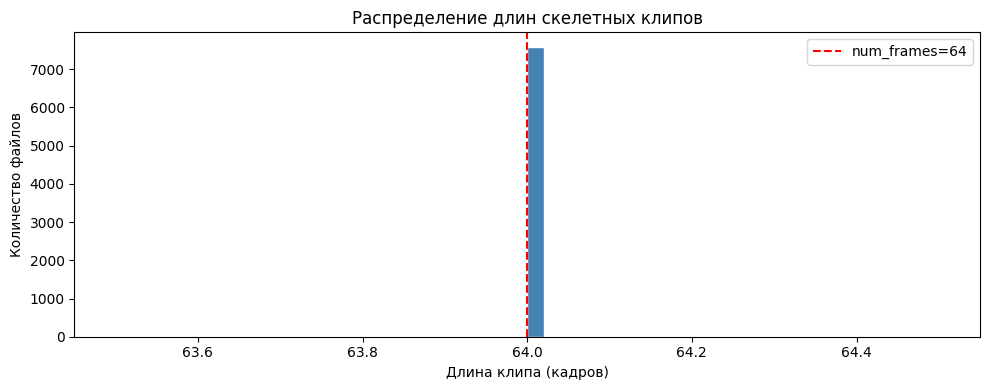

In [76]:
import matplotlib.pyplot as plt

lengths = []
for path in all_npz:
    data = np.load(path, allow_pickle=True)
    lengths.append(data["skeleton"].shape[0])

lengths = np.array(lengths)
print(f"Длина клипов (кадров):")
print(f"  min:    {lengths.min()}")
print(f"  max:    {lengths.max()}")
print(f"  mean:   {lengths.mean():.1f}")
print(f"  median: {np.median(lengths):.1f}")
print(f"  < {cfg.data.num_frames} кадров: {(lengths < cfg.data.num_frames).sum()} файлов")

plt.figure(figsize=(10, 4))
plt.hist(lengths, bins=50, color="steelblue", edgecolor="white")
plt.axvline(cfg.data.num_frames, color="red", linestyle="--",
            label=f"num_frames={cfg.data.num_frames}")
plt.xlabel("Длина клипа (кадров)")
plt.ylabel("Количество файлов")
plt.title("Распределение длин скелетных клипов")
plt.legend()
plt.tight_layout()
plt.show()


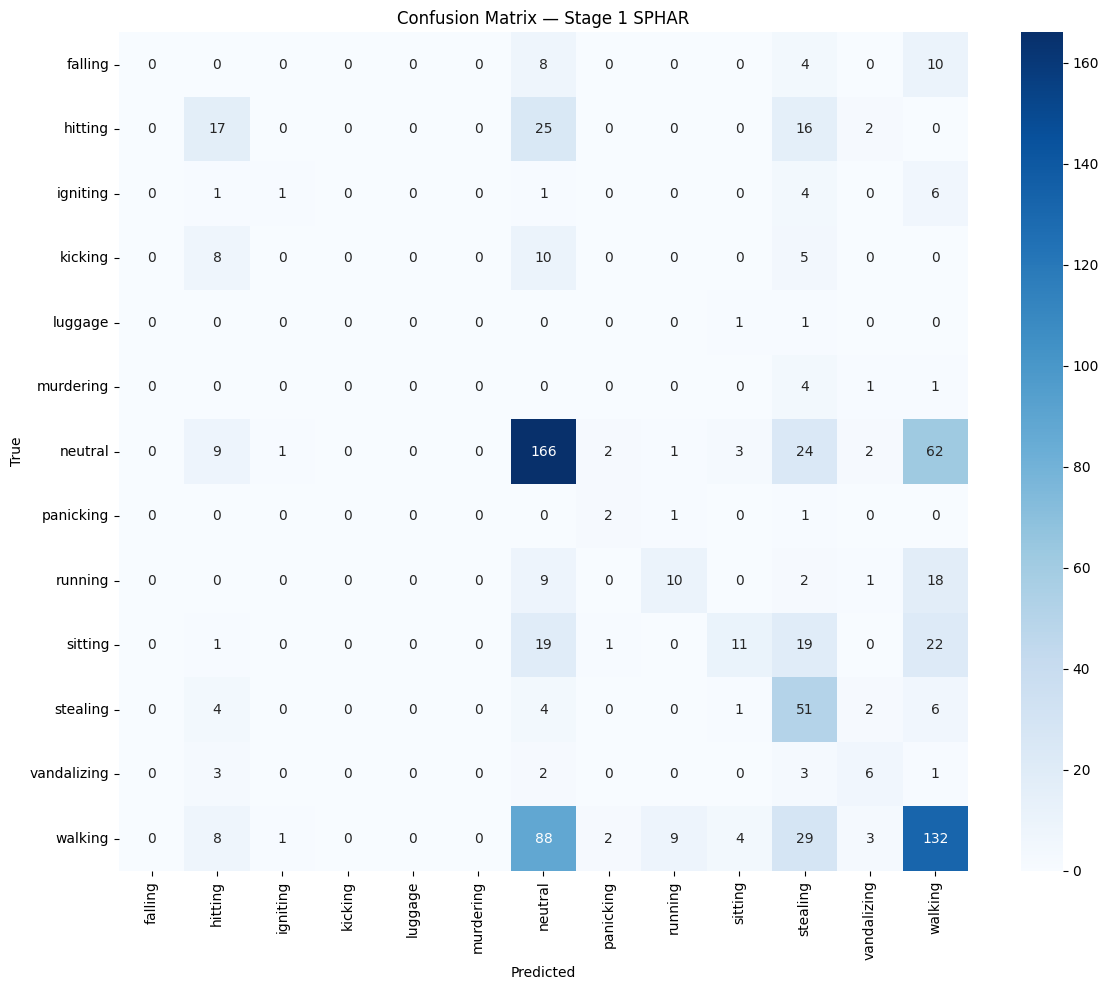

              precision    recall  f1-score   support

     falling      0.000     0.000     0.000        22
     hitting      0.333     0.283     0.306        60
    igniting      0.333     0.077     0.125        13
     kicking      0.000     0.000     0.000        23
     luggage      0.000     0.000     0.000         2
   murdering      0.000     0.000     0.000         6
     neutral      0.500     0.615     0.551       270
   panicking      0.286     0.500     0.364         4
     running      0.476     0.250     0.328        40
     sitting      0.550     0.151     0.237        73
    stealing      0.313     0.750     0.442        68
 vandalizing      0.353     0.400     0.375        15
     walking      0.512     0.478     0.494       276

    accuracy                          0.454       872
   macro avg      0.281     0.270     0.248       872
weighted avg      0.444     0.454     0.428       872



c:\дипломМага\dataset\handlerntu\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\дипломМага\dataset\handlerntu\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\дипломМага\dataset\handlerntu\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

FileNotFoundError: [Errno 2] No such file or directory: 'lightning_logs\\version_1\\metrics.csv'

In [77]:
# Ячейка — финальная оценка
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

# загружаем лучший checkpoint
best_model = STGCNSurveillance.load_from_checkpoint(
    checkpoint_cb.best_model_path,
    cfg=cfg,
)
best_model.eval()
best_model.to("cuda" if torch.cuda.is_available() else "cpu")

all_preds, all_labels = [], []

with torch.no_grad():
    for x, y in dm.val_dataloader():
        x      = x.to(best_model.device)
        logits = best_model(x)
        preds  = logits.argmax(dim=1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(y.tolist())

# ── confusion matrix ──────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    cm, annot=True, fmt="d", ax=ax,
    xticklabels=SPHAR_CLASSES,
    yticklabels=SPHAR_CLASSES,
    cmap="Blues",
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix — Stage 1 SPHAR")
plt.tight_layout()
plt.show()

# ── per-class report ──────────────────────────────────────────────
print(classification_report(
    all_labels, all_preds,
    target_names=SPHAR_CLASSES,
    digits=3,
))

# ── кривые обучения ───────────────────────────────────────────────
log_dirs = sorted(Path("lightning_logs").glob("version_*"))
df = pd.read_csv(log_dirs[-1] / "metrics.csv")

train = df[["epoch", "train/loss_epoch", "train/f1_epoch"]].dropna()
val   = df[["epoch", "val/loss",         "val/f1"]].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train["epoch"], train["train/loss_epoch"], label="train")
axes[0].plot(val["epoch"],   val["val/loss"],           label="val")
axes[0].set_title("Loss"); axes[0].legend()

axes[1].plot(train["epoch"], train["train/f1_epoch"], label="train F1")
axes[1].plot(val["epoch"],   val["val/f1"],           label="val F1")
axes[1].axhline(val["val/f1"].max(), color="gray", linestyle="--",
                label=f"best={val['val/f1'].max():.3f}")
axes[1].set_title("F1"); axes[1].legend()

plt.suptitle("Stage 1 — Training Curves")
plt.tight_layout()
plt.show()

print(f"\nЛучший val/f1: {val['val/f1'].max():.4f} (epoch {int(val['val/f1'].idxmax())})")
print(f"Checkpoint:    {checkpoint_cb.best_model_path}")


# Stage 2

In [57]:
from omegaconf import OmegaConf

BIISK_CLASSES = [
    "cough",
    "call",
    "drink",
    "scratch",
    "sneeze",
    "stretch",
    "wave",
    "wipe",
]

cfg2 = OmegaConf.create({
    "data": {
        # source — SPHAR (уже есть скелеты)
        "skeleton_root":        "data_stage2\\biisk_skeletons",

        # target — ваш датасет с кашлем
        "cough_skeleton_root":  "data_stage2\\biisk_skeletons",
        "cough_video_root":     "data_stage2\\cough_videos",   # оригинальные видео

        "num_frames":    64,
        "num_joints":    17,
        "img_size":      1280,
        "conf_thresh":   0.15,
        "iou_thresh":    0.45,
        "skip_existing": True,
    },
    "model": {
        "in_channels":  2,
        "num_classes":  len(BIISK_CLASSES),      # число классов в вашем датасете
        "dropout":      0.3,
        "hidden_dim":   256,

        # backbone из Stage 1
        "backbone_ckpt": "checkpoints/stage1_surveillance/stage1_backbone.pt",

        # стратегия заморозки:
        # "freeze_all"   — только head обучается (мало данных)
        # "freeze_early" — первые 5 блоков заморожены, последние 2 + head обучаются
        # "full"         — всё обучается (много данных)
        "freeze_strategy": "freeze_early",
    },
    "train": {
        "batch_size":   8,
        "lr":           3e-4,    # ниже чем в Stage 1 — backbone уже обучен
        "lr_backbone":  3e-5,    # backbone обучается с меньшим lr
        "weight_decay": 1e-4,
        "max_epochs":   40,
        "val_split":    0.2,
        "num_workers":  0,
        "seed":         42,
        "ckpt_dir":     "checkpoints/stage2_cough",
        "log_dir":      "logs",
    },
    "uda": {
        # используется только в режиме 2B (без меток)
        "pseudo_conf_thresh":  0.85,   # минимальная уверенность для pseudo label
        "pseudo_start_epoch":  5,      # с какой эпохи начинать pseudo labeling
        "lambda_pseudo":       0.5,    # вес pseudo loss
    }
})


print(OmegaConf.to_yaml(cfg2))

data:
  skeleton_root: data_stage2\biisk_skeletons
  cough_skeleton_root: data_stage2\biisk_skeletons
  cough_video_root: data_stage2\cough_videos
  num_frames: 64
  num_joints: 17
  img_size: 1280
  conf_thresh: 0.15
  iou_thresh: 0.45
  skip_existing: true
model:
  in_channels: 2
  num_classes: 8
  dropout: 0.3
  hidden_dim: 256
  backbone_ckpt: checkpoints/stage1_surveillance/stage1_backbone.pt
  freeze_strategy: freeze_early
train:
  batch_size: 8
  lr: 0.0003
  lr_backbone: 3.0e-05
  weight_decay: 0.0001
  max_epochs: 40
  val_split: 0.2
  num_workers: 0
  seed: 42
  ckpt_dir: checkpoints/stage2_cough
  log_dir: logs
uda:
  pseudo_conf_thresh: 0.85
  pseudo_start_epoch: 5
  lambda_pseudo: 0.5



In [46]:
from pathlib import Path
from collections import Counter

BIISK_ROOT = Path(r"C:\diplommaga\dataset\OpenVINO_SmartCam\dataset\biisc\videos")  # папка, где лежат S001_M_*.avi

assert BIISK_ROOT.exists(), BIISK_ROOT

ACTION_MAP = {
    "CALL": "call",
    "COUG": "cough",
    "DRIN": "drink",
    "SCRA": "scratch",
    "SNEE": "sneeze",
    "STRE": "stretch",
    "WAVE": "wave",
    "WIPE": "wipe",
}

def parse_action(path: Path) -> str | None:
    # S001_M_CALL_STD_FCE[_HF].avi
    name = path.stem  # без .avi
    parts = name.split("_")
    if len(parts) < 4:
        return None
    action_code = parts[2]  # CALL / COUG / ...
    return ACTION_MAP.get(action_code, None)

video_exts = (".avi", ".mp4", ".mov")
all_biisk = []
per_class = Counter()

for p in sorted(BIISK_ROOT.iterdir()):
    if not p.is_file() or p.suffix.lower() not in video_exts:
        continue
    act = parse_action(p)
    if act is None:
        continue
    all_biisk.append((p, act))
    per_class[act] += 1

print(f"Всего видео: {len(all_biisk)}")
for cls in sorted(per_class):
    print(f"  {cls:<8} {per_class[cls]:>5}")


Всего видео: 1920
  call       240
  cough      240
  drink      240
  scratch    240
  sneeze     240
  stretch    240
  wave       240
  wipe       240


In [35]:
BIISK_SKELETON_ROOT = Path("../testyolopose/keypoints")

stats_quality = defaultdict(lambda: {"good": 0, "bad": 0})
for path in BIISK_SKELETON_ROOT.rglob("*.npz"):
    data  = np.load(path, allow_pickle=True)
    seq   = data["keypoints"][:, :, :2]
    valid = (np.abs(seq).sum(axis=(1,2)) > 1e-4).mean()
    cls   = path.parent.name
    if valid >= 0.3:
        stats_quality[cls]["good"] += 1
    else:
        stats_quality[cls]["bad"] += 1

print(f"{'Класс':<10} {'Хороших':>10} {'Плохих':>10}")
print("-" * 32)
for cls in sorted(stats_quality):
    g = stats_quality[cls]["good"]
    b = stats_quality[cls]["bad"]
    print(f"  {cls:<10} {g:>8} {b:>10}")


Класс         Хороших     Плохих
--------------------------------
  yolov8n-pose     1920          0


## CoughSkeletonDataset

In [60]:
import numpy as np
import torch
from torch.utils.data import Dataset
from pathlib import Path


class CoughSkeletonDataset(Dataset):
    """
    Dataset для целевого домена (cough surveillance).

    labeled=True  → обычный режим, возвращает (x, label)
    labeled=False → режим UDA, возвращает только (x,) без меток
                    используется для pseudo labeling
    """

    def __init__(
        self,
        skeleton_root: str,
        classes: list,
        augment:  bool  = False,
        labeled:  bool  = True,
        num_frames: int = 64,
        conf_thresh: float = 0.15,
    ):
        self.augment     = augment
        self.labeled     = labeled
        self.num_frames  = num_frames
        self.conf_thresh = conf_thresh
        self.class2idx   = {c: i for i, c in enumerate(classes)}

        self.samples = []   # (Path, label) или (Path, -1) если unlabeled

        root = Path(skeleton_root)

        if labeled:
            # структура: cough_skeletons/cough/*.npz
            #                           /no_cough/*.npz
            for class_name in classes:
                class_dir = root / class_name
                if not class_dir.exists():
                    print(f"⚠ Нет папки: {class_dir}")
                    continue
                for f in sorted(class_dir.glob("*.npz")):
                    self.samples.append((f, self.class2idx[class_name]))
        else:
            # все .npz без меток (unlabeled target)
            for f in sorted(root.rglob("*.npz")):
                self.samples.append((f, -1))

        print(f"CoughDataset ({'labeled' if labeled else 'unlabeled'}): "
              f"{len(self.samples)} сэмплов")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]

        data = np.load(path, allow_pickle=True)
        seq  = data["skeleton"].astype(np.float32)  # (T, 17, 3)

        # применяем conf threshold
        conf = seq[:, :, 2:]
        xy   = seq[:, :, :2]
        xy   = xy * (conf >= self.conf_thresh)

        seq  = self._normalize(xy)   # (T, 17, 2)

        seq = self._resize_to_num_frames(seq)

        if self.augment:
            seq = self._augment(seq)

        # (T, 17, 2) → (2, T, 17)
        seq = seq.transpose(2, 0, 1)
        x   = torch.from_numpy(seq.copy())

        if self.labeled:
            return x, torch.tensor(label, dtype=torch.long)
        else:
            return x   # для pseudo labeling

    def _normalize(self, seq):
        hip_center    = (seq[:, 11:12, :] + seq[:, 12:13, :]) / 2.0
        seq           = seq - hip_center
        shoulder_dist = np.linalg.norm(
            seq[:, 5, :] - seq[:, 6, :], axis=-1
        ).mean()
        if shoulder_dist > 1e-4:
            seq = seq / shoulder_dist
        return seq.astype(np.float32)

    
    def _resize_to_num_frames(self, seq):
        T_real = seq.shape[0]
        T_desired = self.num_frames

        # равномерно растянуть/сжать по времени до T_desired
        indices = np.linspace(0, T_real - 1, T_desired)
        indices = np.clip(indices, 0, T_real - 1).astype(int)
        return seq[indices]

    def _augment(self, seq):
        # сначала приводим длину к num_frames
        seq = self._resize_to_num_frames(seq)   # (T_desired, 17, 2)

        # дальше — только геометрические аугментации
        if np.random.rand() < 0.5:
            seq = seq.copy()
            seq[:, :, 0] = -seq[:, :, 0]

        if np.random.rand() < 0.5:
            a = np.random.uniform(-15, 15) * np.pi / 180
            c, s = np.cos(a), np.sin(a)
            seq = seq @ np.array([[c, -s], [s, c]], dtype=np.float32).T

        seq = seq + np.random.normal(0, 0.02, seq.shape).astype(np.float32)
        return seq.astype(np.float32)

In [47]:
from pathlib import Path
import numpy as np
from collections import Counter

BIISK_NPZ_ROOT = Path(r"../testyolopose/keypoints/yolov8n-pose")
# BIISK_SKELETON_ROOT = Path("../testyolopose/keypoints")          # где лежат .npz с keypoints
OUT_ROOT       = Path("data_stage2/biisk_skeletons")       # целевая структура

ACTION_MAP = {
    "CALL": "call",
    "COUG": "cough",
    "DRIN": "drink",
    "SCRA": "scratch",
    "SNEE": "sneeze",
    "STRE": "stretch",
    "WAVE": "wave",
    "WIPE": "wipe",
}

def parse_action_from_filename(fname: str) -> str | None:
    # S001_M_CALL_STD_FCE[_HF].avi → CALL
    stem = Path(fname).stem
    parts = stem.split("_")
    if len(parts) < 3:
        return None
    code = parts[2]
    return ACTION_MAP.get(code)

counts = Counter()

for npz_path in BIISK_NPZ_ROOT.glob("*.npz"):
    data = np.load(npz_path, allow_pickle=True)
    filename = str(data["filename"])  # исходное имя видео
    act = parse_action_from_filename(filename)
    if act is None:
        continue

    out_dir = OUT_ROOT / act
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / npz_path.name

    # сохраняем в общем формате с ключом 'skeleton'
    kpts = data["keypoints"].astype(np.float32)    # (T,17,3)
    np.savez_compressed(
        out_path,
        skeleton=kpts,
        class_name=act,
        video=Path(filename).stem,
    )
    counts[act] += 1

print("Разложено по классам:")
for k in sorted(counts):
    print(f"  {k:<6}: {counts[k]:>5}")

KeyboardInterrupt: 

In [53]:
from torch.utils.data import DataLoader, random_split


class CoughDataModule(pl.LightningDataModule):

    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg

    def setup(self, stage=None):
        full_ds = CoughSkeletonDataset(
            skeleton_root = self.cfg.data.cough_skeleton_root,
            classes       = BIISK_CLASSES,
            augment       = False,
            labeled       = True,
            num_frames    = self.cfg.data.num_frames,
            conf_thresh   = self.cfg.data.conf_thresh,
        )

        val_size   = int(len(full_ds) * self.cfg.train.val_split)
        train_size = len(full_ds) - val_size
        generator  = torch.Generator().manual_seed(self.cfg.train.seed)

        self.train_ds, self.val_ds = random_split(
            full_ds, [train_size, val_size], generator=generator
        )
        self.train_ds.dataset.augment = F

        print(f"Train: {len(self.train_ds)} | Val: {len(self.val_ds)}")

    def train_dataloader(self):
        return DataLoader(self.train_ds,
                          batch_size=self.cfg.train.batch_size,
                          shuffle=True,
                          num_workers=self.cfg.train.num_workers)

    def val_dataloader(self):
        return DataLoader(self.val_ds,
                          batch_size=self.cfg.train.batch_size * 2,
                          shuffle=False,
                          num_workers=self.cfg.train.num_workers)

## biisk st-gcn train

### STGCNStage2

In [54]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pytorch_lightning as pl
from torchmetrics import Accuracy, F1Score
from omegaconf import OmegaConf


class STGCNStage2(pl.LightningModule):
    """
    Stage 2: адаптация ST-GCN к cough датасету.

    Стратегии заморозки:
    ─────────────────────────
    freeze_all   → backbone заморожен, только новый head обучается
                   когда: очень мало данных (< 100 сэмплов)

    freeze_early → первые 5 блоков заморожены, блоки 5-6 + head обучаются
                   с разными lr: backbone_lr << head_lr
                   когда: умеренно данных (100-1000 сэмплов)
                   это наш выбор по умолчанию

    full         → всё обучается, backbone с малым lr
                   когда: много данных (> 1000 сэмплов)
    """

    def __init__(self, cfg, cfg1=None):
        super().__init__()
        self.save_hyperparameters(OmegaConf.to_container(cfg, resolve=True))
        self.cfg = cfg

        nc   = cfg.model.num_classes
        drop = cfg.model.dropout
        hdim = cfg.model.hidden_dim

        A = Graph(num_joints=cfg.data.num_joints).get_adjacency()

        # ── backbone из Stage 1 ─────────────────────────────────────
        # используем ту же архитектуру
        self.data_bn  = nn.BatchNorm1d(cfg.model.in_channels * cfg.data.num_joints)
        self.backbone = nn.ModuleList([
            STGCNBlock(cfg.model.in_channels, 64,   A, dropout=drop),
            STGCNBlock(64,   64,   A, dropout=drop),
            STGCNBlock(64,   64,   A, dropout=drop),
            STGCNBlock(64,   128,  A, dropout=drop, stride=2),
            STGCNBlock(128,  128,  A, dropout=drop),
            STGCNBlock(128,  hdim, A, dropout=drop, stride=2),
            STGCNBlock(hdim, hdim, A, dropout=drop),
        ])

        # ── новый head под cough классы ──────────────────────────────
        # head всегда переинициализируется — у Stage 1 другое число классов
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(drop),
            nn.Linear(hdim, nc),
        )

        # ── загружаем веса backbone из Stage 1 ──────────────────────
        self._load_backbone(cfg.model.backbone_ckpt)

        # ── применяем стратегию заморозки ───────────────────────────
        self._apply_freeze_strategy(cfg.model.freeze_strategy)

        # ── метрики ──────────────────────────────────────────────────
        for split in ("train", "val"):
            setattr(self, f"{split}_acc",
                    Accuracy(task="multiclass", num_classes=nc))
            setattr(self, f"{split}_f1",
                    F1Score(task="multiclass", num_classes=nc, average="macro"))

    def _load_backbone(self, ckpt_path: str):
        """Загружает backbone из Stage 1, пропускает head."""
        if not ckpt_path:
            print("Backbone: init from scratch (no ckpt)")
            return
        state = torch.load(ckpt_path, map_location="cpu")

        # файл может быть checkpoint Lightning или наш backbone.pt
        if "backbone_state_dict" in state:
            sd = state["backbone_state_dict"]
        elif "state_dict" in state:
            # Lightning checkpoint — убираем prefix 'model.'
            sd = {k.replace("model.", ""): v
                  for k, v in state["state_dict"].items()}
        else:
            sd = state

        # загружаем только те ключи которые совпадают (backbone + data_bn)
        # head намеренно пропускаем — у него другой размер
        missing, unexpected = self.load_state_dict(sd, strict=False)

        head_keys = [k for k in missing if k.startswith("head")]
        other_missing = [k for k in missing if not k.startswith("head")]

        print(f"✅ Backbone загружен из {ckpt_path}")
        print(f"   Пропущено (head — ожидаемо): {len(head_keys)}")
        if other_missing:
            print(f"   ⚠ Не загружено (неожиданно): {other_missing}")

    def _apply_freeze_strategy(self, strategy: str):
        """Замораживает нужные слои."""
        if strategy == "freeze_all":
            # только head обучается
            for p in self.data_bn.parameters():
                p.requires_grad = False
            for layer in self.backbone:
                for p in layer.parameters():
                    p.requires_grad = False
            print("❄️  freeze_all: обучается только head")

        elif strategy == "freeze_early":
            # замораживаем первые 5 блоков (0-4), обучаем 5-6
            for p in self.data_bn.parameters():
                p.requires_grad = False
            for i, layer in enumerate(self.backbone):
                freeze = i < 5
                for p in layer.parameters():
                    p.requires_grad = not freeze
            frozen = sum(1 for l in self.backbone[:5])
            print(f"❄️  freeze_early: заморожены блоки 0-4, обучаются блоки 5-6 + head")

        elif strategy == "full":
            # всё обучается, backbone с малым lr через param groups
            print("🔓 full: весь backbone обучается (разные lr)")

        # считаем обучаемые параметры
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total     = sum(p.numel() for p in self.parameters())
        print(f"   Обучаемых параметров: {trainable:,} / {total:,} "
              f"({100*trainable/total:.1f}%)")

    def forward(self, x):
        B, C, T, V = x.shape
        x = x.permute(0, 1, 3, 2).contiguous().view(B, C * V, T)
        x = self.data_bn(x)
        x = x.view(B, C, V, T).permute(0, 1, 3, 2)
        for layer in self.backbone:
            x = layer(x)
        return self.head(x)

    def _shared_step(self, batch, split):
        x, y   = batch
        logits = self(x)
        loss   = F.cross_entropy(logits, y)
        preds  = logits.argmax(dim=1)

        getattr(self, f"{split}_acc")(preds, y)
        getattr(self, f"{split}_f1")(preds, y)

        self.log(f"{split}/loss", loss, prog_bar=True, on_epoch=True)
        self.log(f"{split}/acc",  getattr(self, f"{split}_acc"),
                 prog_bar=True, on_epoch=True)
        self.log(f"{split}/f1",   getattr(self, f"{split}_f1"),
                 prog_bar=True, on_epoch=True)
        return loss

    def training_step(self, batch, batch_idx):
        return self._shared_step(batch, "train")

    def validation_step(self, batch, batch_idx):
        self._shared_step(batch, "val")

    def configure_optimizers(self):
        strategy = self.cfg.model.freeze_strategy

        if strategy == "full":
            # две группы параметров с разными lr
            backbone_params = list(self.data_bn.parameters()) + \
                              list(self.backbone.parameters())
            head_params     = list(self.head.parameters())

            param_groups = [
                {"params": backbone_params, "lr": self.cfg.train.lr_backbone},
                {"params": head_params,     "lr": self.cfg.train.lr},
            ]
        else:
            # только обучаемые параметры
            param_groups = filter(lambda p: p.requires_grad, self.parameters())

        opt = torch.optim.AdamW(
            param_groups,
            weight_decay = self.cfg.train.weight_decay,
            # lr здесь не нужен если уже в param_groups,
            # но нужен для freeze_all/freeze_early
            **({} if strategy == "full" else {"lr": self.cfg.train.lr}),
        )
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            opt, T_max=self.cfg.train.max_epochs, eta_min=1e-6
        )
        return {"optimizer": opt, "lr_scheduler": scheduler}

### CoughDataModule

In [55]:
from torch.utils.data import DataLoader, random_split

class CoughDataModule(pl.LightningDataModule):

    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg

    def setup(self, stage=None):
        full_ds = CoughSkeletonDataset(
            skeleton_root = self.cfg.data.cough_skeleton_root,
            classes       = BIISK_CLASSES,
            augment       = False,
            labeled       = True,
            num_frames    = self.cfg.data.num_frames,
            conf_thresh   = self.cfg.data.conf_thresh,
        )

        val_size   = int(len(full_ds) * self.cfg.train.val_split)
        train_size = len(full_ds) - val_size
        generator  = torch.Generator().manual_seed(self.cfg.train.seed)

        self.train_ds, self.val_ds = random_split(
            full_ds, [train_size, val_size], generator=generator
        )
        self.train_ds.dataset.augment = False  # аугментация только на train

        print(f"Train: {len(self.train_ds)} | Val: {len(self.val_ds)}")

    def train_dataloader(self):
        return DataLoader(self.train_ds,
                          batch_size=self.cfg.train.batch_size,
                          shuffle=True,
                          num_workers=self.cfg.train.num_workers)

    def val_dataloader(self):
        return DataLoader(self.val_ds,
                          batch_size=self.cfg.train.batch_size * 2,
                          shuffle=False,
                          num_workers=self.cfg.train.num_workers)

### start train

In [58]:
# Загрузи в Biisk Stage 2
cfg2.model.backbone_ckpt = "checkpoints/ntu_backbone.pt"
model_biisk_ntu = STGCNStage2(cfg2)

✅ Backbone загружен из checkpoints/ntu_backbone.pt
   Пропущено (head — ожидаемо): 2
   ⚠ Не загружено (неожиданно): ['data_bn.weight', 'data_bn.bias', 'data_bn.running_mean', 'data_bn.running_var', 'backbone.0.A', 'backbone.0.gcn.weight', 'backbone.0.gcn.bias', 'backbone.0.tcn.0.weight', 'backbone.0.tcn.0.bias', 'backbone.0.tcn.0.running_mean', 'backbone.0.tcn.0.running_var', 'backbone.0.tcn.2.weight', 'backbone.0.tcn.2.bias', 'backbone.0.tcn.3.weight', 'backbone.0.tcn.3.bias', 'backbone.0.tcn.3.running_mean', 'backbone.0.tcn.3.running_var', 'backbone.0.skip.0.weight', 'backbone.0.skip.0.bias', 'backbone.0.skip.1.weight', 'backbone.0.skip.1.bias', 'backbone.0.skip.1.running_mean', 'backbone.0.skip.1.running_var', 'backbone.1.A', 'backbone.1.gcn.weight', 'backbone.1.gcn.bias', 'backbone.1.tcn.0.weight', 'backbone.1.tcn.0.bias', 'backbone.1.tcn.0.running_mean', 'backbone.1.tcn.0.running_var', 'backbone.1.tcn.2.weight', 'backbone.1.tcn.2.bias', 'backbone.1.tcn.3.weight', 'backbone.1.tcn.

In [61]:
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.loggers import CSVLogger

pl.seed_everything(cfg2.train.seed)
torch.set_float32_matmul_precision("medium")

checkpoint_cb2 = ModelCheckpoint(
    dirpath    = cfg2.train.ckpt_dir,
    filename   = "stage2-{epoch:02d}-{val/f1:.3f}",
    monitor    = "val/f1",
    mode       = "max",
    save_top_k = 3,
    save_last  = True,
)

early_stop_cb2 = EarlyStopping(
    monitor  = "val/f1",
    patience = 10,
    mode     = "max",
)

csv_logger2 = CSVLogger(save_dir="logs_stage2", name="stgcn_cough_stage2")

trainer2 = pl.Trainer(
    max_epochs  = cfg2.train.max_epochs,
    accelerator = "auto",
    devices     = 1,
    callbacks   = [checkpoint_cb2, early_stop_cb2],
    logger      = csv_logger2,
)

model2 = STGCNStage2(cfg2)
dm2    = CoughDataModule(cfg2)

trainer2.fit(model2, datamodule=dm2)

print(f"\nЛучший checkpoint: {checkpoint_cb2.best_model_path}")
print(f"Лучший val/f1:     {checkpoint_cb2.best_model_score:.4f}")

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
c:\diplommaga\dataset\handlerntu\env\Lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:881: Checkpoint directory C:\diplommaga\dataset\handlerntu\fine_tuning\checkpoints\stage2_cough exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode  | FLOPs
-----------------------------------------------------------------
0 | data_bn   | BatchNorm1d        | 68     | train | 0    
1 | backbone  | ModuleList         | 1.8 M  | train | 0    
2 | head      | Sequential         | 2.1 K  | train | 0    
3 | train_acc | MulticlassAccuracy | 0      | train | 0    
4 | train_f1  | MulticlassF1Score  | 0    

✅ Backbone загружен из checkpoints/ntu_backbone.pt
   Пропущено (head — ожидаемо): 2
   ⚠ Не загружено (неожиданно): ['data_bn.weight', 'data_bn.bias', 'data_bn.running_mean', 'data_bn.running_var', 'backbone.0.A', 'backbone.0.gcn.weight', 'backbone.0.gcn.bias', 'backbone.0.tcn.0.weight', 'backbone.0.tcn.0.bias', 'backbone.0.tcn.0.running_mean', 'backbone.0.tcn.0.running_var', 'backbone.0.tcn.2.weight', 'backbone.0.tcn.2.bias', 'backbone.0.tcn.3.weight', 'backbone.0.tcn.3.bias', 'backbone.0.tcn.3.running_mean', 'backbone.0.tcn.3.running_var', 'backbone.0.skip.0.weight', 'backbone.0.skip.0.bias', 'backbone.0.skip.1.weight', 'backbone.0.skip.1.bias', 'backbone.0.skip.1.running_mean', 'backbone.0.skip.1.running_var', 'backbone.1.A', 'backbone.1.gcn.weight', 'backbone.1.gcn.bias', 'backbone.1.tcn.0.weight', 'backbone.1.tcn.0.bias', 'backbone.1.tcn.0.running_mean', 'backbone.1.tcn.0.running_var', 'backbone.1.tcn.2.weight', 'backbone.1.tcn.2.bias', 'backbone.1.tcn.3.weight', 'backbone.1.tcn.

c:\diplommaga\dataset\handlerntu\env\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


c:\diplommaga\dataset\handlerntu\env\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Epoch 39: 100%|██████████| 192/192 [00:05<00:00, 33.83it/s, v_num=10, train/loss_step=1.380, train/acc_step=0.625, train/f1_step=0.433, val/loss=1.720, val/acc=0.398, val/f1=0.360, train/loss_epoch=1.450, train/acc_epoch=0.453, train/f1_epoch=0.443] 

`Trainer.fit` stopped: `max_epochs=40` reached.


Epoch 39: 100%|██████████| 192/192 [00:05<00:00, 32.98it/s, v_num=10, train/loss_step=1.380, train/acc_step=0.625, train/f1_step=0.433, val/loss=1.720, val/acc=0.398, val/f1=0.360, train/loss_epoch=1.450, train/acc_epoch=0.453, train/f1_epoch=0.443]

Лучший checkpoint: C:\diplommaga\dataset\handlerntu\fine_tuning\checkpoints\stage2_cough\stage2-epoch=39-val/f1=0.360.ckpt
Лучший val/f1:     0.3598


### Поиск проблемы


In [31]:
dm2 = CoughDataModule(cfg2)
dm2.setup("fit")   # создаёт train/val

train_loader = dm2.train_dataloader()
train_ds = train_loader.dataset

import numpy as np

ys = [int(label) for _, label in train_ds]
print(np.unique(ys, return_counts=True))

NameError: name 'CoughSkeletonDataset' is not defined

In [43]:
dm2.setup("fit")
val_loader = dm2.val_dataloader()
val_ds = val_loader.dataset

from collections import defaultdict
import random

by_class = defaultdict(list)
for i in range(len(val_ds)):
    x, y = val_ds[i]
    by_class[int(y)].append(i)

# выберем по 5 индексов на класс
sample_indices = []
for c, idxs in by_class.items():
    sample_indices += random.sample(idxs, min(5, len(idxs)))
print("Всего примеров для просмотра:", len(sample_indices))

CoughDataset (labeled): 1920 сэмплов
Train: 1536 | Val: 384
Всего примеров для просмотра: 40


In [68]:
from torch.utils.data import DataLoader
import torch
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

ckpt_path = "checkpoints\\stage2_cough\\last-v3_ntu-biisk.ckpt"
model2 = STGCNStage2.load_from_checkpoint(ckpt_path, cfg=cfg2)
model2.eval().cuda()

dm2.setup("fit")
val_loader = dm2.val_dataloader()

all_y = []
all_yhat = []

with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.cuda()
        logits = model2(xb)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_y.append(yb.numpy())
        all_yhat.append(preds)

y_true = np.concatenate(all_y)
y_pred = np.concatenate(all_yhat)

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=BIISK_CLASSES))

✅ Backbone загружен из checkpoints/ntu_backbone.pt
   Пропущено (head — ожидаемо): 2
   ⚠ Не загружено (неожиданно): ['data_bn.weight', 'data_bn.bias', 'data_bn.running_mean', 'data_bn.running_var', 'backbone.0.A', 'backbone.0.gcn.weight', 'backbone.0.gcn.bias', 'backbone.0.tcn.0.weight', 'backbone.0.tcn.0.bias', 'backbone.0.tcn.0.running_mean', 'backbone.0.tcn.0.running_var', 'backbone.0.tcn.2.weight', 'backbone.0.tcn.2.bias', 'backbone.0.tcn.3.weight', 'backbone.0.tcn.3.bias', 'backbone.0.tcn.3.running_mean', 'backbone.0.tcn.3.running_var', 'backbone.0.skip.0.weight', 'backbone.0.skip.0.bias', 'backbone.0.skip.1.weight', 'backbone.0.skip.1.bias', 'backbone.0.skip.1.running_mean', 'backbone.0.skip.1.running_var', 'backbone.1.A', 'backbone.1.gcn.weight', 'backbone.1.gcn.bias', 'backbone.1.tcn.0.weight', 'backbone.1.tcn.0.bias', 'backbone.1.tcn.0.running_mean', 'backbone.1.tcn.0.running_var', 'backbone.1.tcn.2.weight', 'backbone.1.tcn.2.bias', 'backbone.1.tcn.3.weight', 'backbone.1.tcn.

In [69]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# исходные классы
BIISK_CLASSES = [
    "cough",
    "call",
    "drink",
    "scratch",
    "sneeze",
    "stretch",
    "wave",
    "wipe",
]

# хотим склеить cough + sneeze в один класс "resp"
merge_map = {
    "cough":  "resp",
    "sneeze": "resp",
    "call":   "call",
    "drink":  "drink",
    "scratch":"scratch",
    "stretch":"stretch",
    "wave":   "wave",
    "wipe":   "wipe",
}

# строим новую разметку классов
merged_classes = []
for name in BIISK_CLASSES:
    new_name = merge_map[name]
    if new_name not in merged_classes:
        merged_classes.append(new_name)

print("Merged classes:", merged_classes)

# функция для преобразования меток по индексу → новый индекс
name_by_idx = {i: cls for i, cls in enumerate(BIISK_CLASSES)}
idx_by_name_merged = {name: i for i, name in enumerate(merged_classes)}

def merge_labels(y):
    out = []
    for idx in y:
        old_name = name_by_idx[int(idx)]
        new_name = merge_map[old_name]
        new_idx  = idx_by_name_merged[new_name]
        out.append(new_idx)
    return np.array(out, dtype=int)

y_true_merged = merge_labels(y_true)
y_pred_merged = merge_labels(y_pred)

cm_merged = confusion_matrix(y_true_merged, y_pred_merged)
print(cm_merged)
print(classification_report(y_true_merged, y_pred_merged,
                            target_names=merged_classes))

Merged classes: ['resp', 'call', 'drink', 'scratch', 'stretch', 'wave', 'wipe']
[[52 26  5  2  1  2 17]
 [ 3 20  5  0  1  6  9]
 [ 1 19 16  0  4  2  3]
 [ 9 10 11  0  5  7  0]
 [ 4  1  9  0 19  6  5]
 [ 8 10 10  0  7 18  0]
 [ 0  2  2  0  0  1 46]]
              precision    recall  f1-score   support

        resp       0.68      0.50      0.57       105
        call       0.23      0.45      0.30        44
       drink       0.28      0.36      0.31        45
     scratch       0.00      0.00      0.00        42
     stretch       0.51      0.43      0.47        44
        wave       0.43      0.34      0.38        53
        wipe       0.57      0.90      0.70        51

    accuracy                           0.45       384
   macro avg       0.39      0.43      0.39       384
weighted avg       0.44      0.45      0.43       384



### Бинарная классификация для cough+sneeez vs background

In [45]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# индексы cough и sneeze в мультиклассе
ci = BIISK_CLASSES.index("cough")
si = BIISK_CLASSES.index("sneeze")

# 1 = respiratory (cough+sneeze), 0 = background (остальные)
def to_binary(y_multi):
    y_bin = np.zeros_like(y_multi, dtype=int)
    y_bin[(y_multi == ci) | (y_multi == si)] = 1
    return y_bin

y_true_bin = to_binary(y_true)
y_pred_bin = to_binary(y_pred)

# названия классов для отчёта
BIN_CLASSES = ["background", "resp"]  # resp = cough+sneeze

cm_bin = confusion_matrix(y_true_bin, y_pred_bin)
print("Binary confusion matrix (background vs resp):")
print(cm_bin)
print()

print("Binary classification report:")
print(classification_report(y_true_bin, y_pred_bin, target_names=BIN_CLASSES))

Binary confusion matrix (background vs resp):
[[258  21]
 [ 57  48]]

Binary classification report:
              precision    recall  f1-score   support

  background       0.82      0.92      0.87       279
        resp       0.70      0.46      0.55       105

    accuracy                           0.80       384
   macro avg       0.76      0.69      0.71       384
weighted avg       0.79      0.80      0.78       384



In [65]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# исходные классы
BIISK_CLASSES = [
    "cough",
    "call",
    "drink",
    "scratch",
    "sneeze",
    "stretch",
    "wave",
    "wipe",
]

# хотим склеить cough + sneeze в один класс "resp"
merge_map = {
    "cough":  "resp",
    "sneeze": "resp",
    "call":   "call",
    "drink":  "drink",
    "scratch":"scratch",
    "stretch":"stretch",
    "wave":   "wave",
    "wipe":   "wipe",
}

# строим новую разметку классов
merged_classes = []
for name in BIISK_CLASSES:
    new_name = merge_map[name]
    if new_name not in merged_classes:
        merged_classes.append(new_name)

print("Merged classes:", merged_classes)

# функция для преобразования меток по индексу → новый индекс
name_by_idx = {i: cls for i, cls in enumerate(BIISK_CLASSES)}
idx_by_name_merged = {name: i for i, name in enumerate(merged_classes)}

def merge_labels(y):
    out = []
    for idx in y:
        old_name = name_by_idx[int(idx)]
        new_name = merge_map[old_name]
        new_idx  = idx_by_name_merged[new_name]
        out.append(new_idx)
    return np.array(out, dtype=int)

y_true_merged = merge_labels(y_true)
y_pred_merged = merge_labels(y_pred)

cm_merged = confusion_matrix(y_true_merged, y_pred_merged)
print(cm_merged)
print(classification_report(y_true_merged, y_pred_merged,
                            target_names=merged_classes))

Merged classes: ['resp', 'call', 'drink', 'scratch', 'stretch', 'wave', 'wipe']
[[48 39  8  6  0  1  3]
 [ 4 22 11  2  1  0  4]
 [ 2 10 23  5  0  3  2]
 [ 6  8 16  6  0  6  0]
 [ 4  3  2  4 17 14  0]
 [ 4 11  9 11  3 14  1]
 [ 1  9  6  0  1  1 33]]
              precision    recall  f1-score   support

        resp       0.70      0.46      0.55       105
        call       0.22      0.50      0.30        44
       drink       0.31      0.51      0.38        45
     scratch       0.18      0.14      0.16        42
     stretch       0.77      0.39      0.52        44
        wave       0.36      0.26      0.30        53
        wipe       0.77      0.65      0.70        51

    accuracy                           0.42       384
   macro avg       0.47      0.42      0.42       384
weighted avg       0.51      0.42      0.44       384



Проверка сколько кашля попало в чихани и наоборот

In [88]:
import torch
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

# Загружаем лучший чекпоинт
ckpt_path = "checkpoints\\stage2_cough\\last-v1.ckpt"
model2_eval = STGCNStage2.load_from_checkpoint(ckpt_path, cfg=cfg2)
model2_eval.eval().cuda()

# Берём val датасет
dm2.setup("fit")
val_loader = dm2.val_dataloader()

all_y    = []
all_yhat = []

with torch.no_grad():
    for xb, yb in val_loader:
        xb    = xb.cuda()
        preds = torch.argmax(model2_eval(xb), dim=1).cpu().numpy()
        all_y.append(yb.numpy())
        all_yhat.append(preds)

y_true = np.concatenate(all_y)
y_pred = np.concatenate(all_yhat)

# Confusion matrix → DataFrame для красивого вывода
cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(cm, index=BIISK_CLASSES, columns=BIISK_CLASSES)
cm_df.index.name   = "True \\ Pred"

print(cm_df.to_string())
print()

# Конкретно cough → sneeze и sneeze → cough
ci = BIISK_CLASSES.index("cough")
si = BIISK_CLASSES.index("sneeze")

print(f"cough  предсказан как sneeze: {cm[ci][si]}")
print(f"sneeze предсказан как cough:  {cm[si][ci]}")
print()

# Полный отчёт per-class
print(classification_report(y_true, y_pred, target_names=BIISK_CLASSES))

✅ Backbone загружен из checkpoints/stage1_surveillance/stage1_backbone.pt
   Пропущено (head — ожидаемо): 2
🔓 full: весь backbone обучается (разные lr)
   Обучаемых параметров: 1,766,668 / 1,766,668 (100.0%)
CoughDataset (labeled): 1920 сэмплов
Train: 1536 | Val: 384
             cough  call  drink  scratch  sneeze  stretch  wave  wipe
True \ Pred                                                          
cough           11    21      5        4       7        0     0     2
call             4    22     11        2       0        1     0     4
drink            0    10     23        5       2        0     3     2
scratch          2     8     16        6       4        0     6     0
sneeze          12    18      3        2      18        0     1     1
stretch          3     3      2        4       1       17    14     0
wave             2    11      9       11       2        3    14     1
wipe             1     9      6        0       0        1     1    33

cough  предсказан как sneeze: 7

In [34]:
dm2.setup("fit")
train_loader = dm2.train_dataloader()
train_ds = train_loader.dataset          # это Subset

base_ds = train_ds.dataset               # исходный CoughDataset
indices = train_ds.indices               # индексы внутри base_ds

print(type(base_ds), len(base_ds))
print(len(indices), "subset indices")

for i in range(20):
    idx = indices[i]
    path, label = base_ds.samples[idx]
    print(label, BIISK_CLASSES[label], "|", path)

CoughDataset (labeled): 1920 сэмплов
Train: 1536 | Val: 384
<class '__main__.CoughSkeletonDataset'> 1920
1536 subset indices
0 cough | data_stage2\biisk_skeletons\cough\S009_M_COUG_WLK_FCE.npz
0 cough | data_stage2\biisk_skeletons\cough\S003_M_COUG_WLK_LFT_HF.npz
4 sneeze | data_stage2\biisk_skeletons\sneeze\S009_M_SNEE_STD_FCE.npz
6 wave | data_stage2\biisk_skeletons\wave\S013_F_WAVE_WLK_FCE_HF.npz
1 call | data_stage2\biisk_skeletons\call\S010_F_CALL_WLK_FCE.npz
1 call | data_stage2\biisk_skeletons\call\S001_M_CALL_STD_RGT_HF.npz
3 scratch | data_stage2\biisk_skeletons\scratch\S006_M_SCRA_WLK_RGT.npz
5 stretch | data_stage2\biisk_skeletons\stretch\S011_F_STRE_STD_LFT_HF.npz
0 cough | data_stage2\biisk_skeletons\cough\S012_M_COUG_WLK_RGT.npz
7 wipe | data_stage2\biisk_skeletons\wipe\S006_M_WIPE_STD_RGT_HF.npz
6 wave | data_stage2\biisk_skeletons\wave\S013_F_WAVE_STD_RGT.npz
6 wave | data_stage2\biisk_skeletons\wave\S003_M_WAVE_WLK_LFT_HF.npz
0 cough | data_stage2\biisk_skeletons\cough

### Проверка сглаживания 

In [70]:
from scipy.signal import savgol_filter
import torch
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

def smooth_skeleton_batch(xb, window=7, polyorder=2):
    arr = xb.cpu().numpy()
    arr = savgol_filter(arr, window_length=window, polyorder=polyorder, axis=2)
    return torch.tensor(arr, dtype=torch.float32)

def run_eval(model, loader, smooth=False, window=7):
    all_y, all_yhat = [], []
    with torch.no_grad():
        for xb, yb in loader:
            if smooth:
                xb = smooth_skeleton_batch(xb, window=window)
            xb = xb.cuda()
            preds = torch.argmax(model(xb), dim=1).cpu().numpy()
            all_y.append(yb.numpy())
            all_yhat.append(preds)
    return np.concatenate(all_y), np.concatenate(all_yhat)

# Baseline (без сглаживания)
y_true, y_pred_raw = run_eval(model2, val_loader, smooth=False)
print("=== RAW (no smoothing) ===")
print(classification_report(y_true, y_pred_raw, target_names=BIISK_CLASSES))

# С Savitzky-Golay (window=7)
_, y_pred_sg7 = run_eval(model2, val_loader, smooth=True, window=7)
print("=== Savitzky-Golay window=7 ===")
print(classification_report(y_true, y_pred_sg7, target_names=BIISK_CLASSES))

# С более агрессивным сглаживанием (window=11)
_, y_pred_sg11 = run_eval(model2, val_loader, smooth=True, window=11)
print("=== Savitzky-Golay window=11 ===")
print(classification_report(y_true, y_pred_sg11, target_names=BIISK_CLASSES))

=== RAW (no smoothing) ===
              precision    recall  f1-score   support

       cough       0.42      0.20      0.27        50
        call       0.23      0.45      0.30        44
       drink       0.28      0.36      0.31        45
     scratch       0.00      0.00      0.00        42
      sneeze       0.45      0.44      0.44        55
     stretch       0.51      0.43      0.47        44
        wave       0.43      0.34      0.38        53
        wipe       0.57      0.90      0.70        51

    accuracy                           0.40       384
   macro avg       0.36      0.39      0.36       384
weighted avg       0.37      0.40      0.37       384

=== Savitzky-Golay window=7 ===
              precision    recall  f1-score   support

       cough       0.43      0.18      0.25        50
        call       0.22      0.39      0.28        44
       drink       0.29      0.31      0.30        45
     scratch       0.00      0.00      0.00        42
      sneeze       

## Stage 3 NTU flu dataset дообучение + benchmark


In [ ]:
cfg_ntu.model.backbone_ckpt = "checkpoints/stage1_surveillance/stage1_backbone.pt"
cfg_ntu.data.skeleton_root = "../ntu_flu_skeletons"  # папка, где лежат skeleton.npz для NTU (можно сгенерировать по примеру BIISK)

In [36]:
from ntu_flu_config import cfg_ntu
# from your_model_file import STGCNStage2   # тот же файл, откуда брал для Biisk

model_ntu = STGCNStage2(cfg_ntu)

✅ Backbone загружен из checkpoints/stage1_surveillance/stage1_backbone.pt
   Пропущено (head — ожидаемо): 2
❄️  freeze_early: заморожены блоки 0-4, обучаются блоки 5-6 + head
   Обучаемых параметров: 1,317,901 / 1,767,953 (74.5%)


In [37]:
from ntu_flu_config  import cfg_ntu, NTU_FLU_CLASSES

from ntu_flu_dataset import NTUFluDataModule
from pytorch_lightning.loggers import TensorBoardLogger
import pytorch_lightning as pl

dm  = NTUFluDataModule(cfg_ntu)
dm.setup("fit")

tb  = TensorBoardLogger(cfg_ntu.train.log_dir, name="baseline_no_attn")
trainer = pl.Trainer(
    max_epochs=cfg_ntu.train.max_epochs,
    logger=tb
)
trainer.fit(model_ntu, datamodule=dm)

# Запуск TensorBoard:
# tensorboard --logdir logs/ntu_flu

# ── Бенчмарк по CCTV-пресетам ────────────────────────────────────────────
from sklearn.metrics import classification_report
import torch, numpy as np

model_ntu.eval().cuda()

for preset_key, bench_ds in dm.benchmark_datasets.items():
    loader = dm.benchmark_dataloader(preset_key)
    ys, yhats = [], []
    with torch.no_grad():
        for xb, yb in loader:
            preds = torch.argmax(model_ntu(xb.cuda()), dim=1).cpu()
            ys.append(yb.numpy()); yhats.append(preds.numpy())
    y_true = np.concatenate(ys)
    y_pred = np.concatenate(yhats)
    print(f"\n=== Benchmark: {preset_key} ===")
    print(classification_report(y_true, y_pred, target_names=NTU_FLU_CLASSES))

NTUFluDataset [no-aug] view=front: 12360 сэмплов | 13 классов
NTUFluDataset [3D-aug+2D-aug] view=front: 12360 сэмплов | 13 классов
NTUFluDataset [no-aug+bench:CCTV Front (-15°)] view=front: 12360 сэмплов | 13 классов
NTUFluDataset [no-aug+bench:CCTV Front (-30°)] view=front: 12360 сэмплов | 13 классов


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


NTUFluDataset [no-aug+bench:CCTV Side (-30°)] view=front: 12360 сэмплов | 13 классов
NTUFluDataset [no-aug+bench:CCTV Back] view=front: 12360 сэмплов | 13 классов
NTUFluDataset [no-aug+bench:CCTV 90 x, 30y] view=front: 12360 сэмплов | 13 классов

Train: 9888 | Val: 2472
Benchmark датасеты: ['cctv_front_15', 'cctv_front_30', 'cctv_side_30', 'cctv_back', 'cctv_right_90_30']
NTUFluDataset [no-aug] view=front: 12360 сэмплов | 13 классов
NTUFluDataset [3D-aug+2D-aug] view=front: 12360 сэмплов | 13 классов
NTUFluDataset [no-aug+bench:CCTV Front (-15°)] view=front: 12360 сэмплов | 13 классов
NTUFluDataset [no-aug+bench:CCTV Front (-30°)] view=front: 12360 сэмплов | 13 классов
NTUFluDataset [no-aug+bench:CCTV Side (-30°)] view=front: 12360 сэмплов | 13 классов
NTUFluDataset [no-aug+bench:CCTV Back] view=front: 12360 сэмплов | 13 классов
NTUFluDataset [no-aug+bench:CCTV 90 x, 30y] view=front: 12360 сэмплов | 13 классов

Train: 9888 | Val: 2472
Benchmark датасеты: ['cctv_front_15', 'cctv_front_3

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode  | FLOPs
-----------------------------------------------------------------
0 | data_bn   | BatchNorm1d        | 68     | train | 0    
1 | backbone  | ModuleList         | 1.8 M  | train | 0    
2 | head      | Sequential         | 3.3 K  | train | 0    
3 | train_acc | MulticlassAccuracy | 0      | train | 0    
4 | train_f1  | MulticlassF1Score  | 0      | train | 0    
5 | val_acc   | MulticlassAccuracy | 0      | train | 0    
6 | val_f1    | MulticlassF1Score  | 0      | train | 0    
-----------------------------------------------------------------
1.3 M     Trainable params
450 K     Non-trainable params
1.8 M     Total params
7.072     Total estimated model params size (MB)
87        Modules in train mode
0         Modules in eval mode
0         Total Flops


Epoch 49: 100%|██████████| 618/618 [00:58<00:00, 10.57it/s, v_num=2, train/loss_step=1.690, train/acc_step=0.375, train/f1_step=0.295, val/loss=1.800, val/acc=0.405, val/f1=0.392, train/loss_epoch=1.620, train/acc_epoch=0.442, train/f1_epoch=0.435]  

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 618/618 [00:58<00:00, 10.56it/s, v_num=2, train/loss_step=1.690, train/acc_step=0.375, train/f1_step=0.295, val/loss=1.800, val/acc=0.405, val/f1=0.392, train/loss_epoch=1.620, train/acc_epoch=0.442, train/f1_epoch=0.435]

=== Benchmark: cctv_front_15 ===
              precision    recall  f1-score   support

   blow_nose       0.21      0.26      0.23       960
 brush_teeth       0.42      0.45      0.43       948
    clapping       0.24      0.08      0.12       948
       cough       0.48      0.37      0.42       948
       drink       0.64      0.10      0.18       948
   hand_wave       0.74      0.15      0.25       948
      nausea       0.90      0.41      0.56       948
    nod_head       0.69      0.88      0.77       948
  phone_call       0.23      0.19      0.20       948
   rub_hands       0.30      0.42      0.35       948
       sniff       0.27      0.57      0.36       960
   wipe_face       0.57      0.28      0.38       948
        yawn  

In [52]:
# Сохрани NTU-backbone
torch.save(model_ntu.backbone.state_dict(), "checkpoints/ntu_backbone.pt")



In [32]:
from ntu_flu_dataset import NTUFluDataset
from ntu_flu_config import cfg_ntu, NTU_FLU_CLASSES

root = Path(cfg_ntu.data.skeleton_root)
print("root:", root, "exists:", root.exists())

for cls in NTU_FLU_CLASSES:
    p = root / cls
    files = list(p.glob("*.skeleton"))
    print(f"{cls:<12} | dir exists={p.exists()} | files={len(files)}")

root: ..\ntu_flu_skeletons exists: True
blow_nose    | dir exists=True | files=960
brush_teeth  | dir exists=True | files=948
clapping     | dir exists=True | files=948
cough        | dir exists=True | files=948
drink        | dir exists=True | files=948
hand_wave    | dir exists=True | files=948
nausea       | dir exists=True | files=948
nod_head     | dir exists=True | files=948
phone_call   | dir exists=True | files=948
rub_hands    | dir exists=True | files=948
sniff        | dir exists=True | files=960
wipe_face    | dir exists=True | files=948
yawn         | dir exists=True | files=960


### NTU без backbone


In [42]:
# 1. Пути и импорты
# <!-- import sys
# sys.path.append(r"c:\diplommaga\dataset\handlerntu\fine_tuning") -->

from ntu_flu_config  import cfg_ntu
from ntu_flu_dataset import NTUFluDataModule
# from your_model_file import STGCNStage2   # замени на реальное имя файла с моделью
from pytorch_lightning.loggers import TensorBoardLogger
import pytorch_lightning as pl

# 2. Отключаем Stage1-backbone для NTU
cfg_ntu.model.backbone_ckpt = ""          # или None, если в _load_backbone так проверяешь
cfg_ntu.model.freeze_strategy = "full"    # всё обучаем, раз инициализация с нуля
cfg_ntu.train.lr_backbone = cfg_ntu.train.lr   # можно выровнять lr

# 3. Создаём модель и DataModule
model_ntu = STGCNStage2(cfg_ntu)          # внутри _load_backbone должно просто вернуть, если путь пустой
dm_ntu    = NTUFluDataModule(cfg_ntu)
dm_ntu.setup("fit")

# 4. Логгер для TensorBoard
tb_logger = TensorBoardLogger(
    save_dir=cfg_ntu.train.log_dir,
    name="ntu_from_scratch"
)

# 5. Trainer и запуск обучения
trainer_ntu = pl.Trainer(
    max_epochs=cfg_ntu.train.max_epochs,
    logger=tb_logger,
    default_root_dir=cfg_ntu.train.ckpt_dir,
    accelerator="gpu",
    devices=1,
)

trainer_ntu.fit(model_ntu, datamodule=dm_ntu)

# 6. После обучения можно запустить:
# tensorboard --logdir logs/ntu_flu

Backbone: init from scratch (no ckpt)
🔓 full: весь backbone обучается (разные lr)
   Обучаемых параметров: 1,767,953 / 1,767,953 (100.0%)
NTUFluDataset [no-aug] view=front: 12360 сэмплов | 13 классов
NTUFluDataset [3D-aug+2D-aug] view=front: 12360 сэмплов | 13 классов
NTUFluDataset [no-aug+bench:CCTV Front (-15°)] view=front: 12360 сэмплов | 13 классов
NTUFluDataset [no-aug+bench:CCTV Front (-30°)] view=front: 12360 сэмплов | 13 классов


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


NTUFluDataset [no-aug+bench:CCTV Side (-30°)] view=front: 12360 сэмплов | 13 классов
NTUFluDataset [no-aug+bench:CCTV Back] view=front: 12360 сэмплов | 13 классов
NTUFluDataset [no-aug+bench:CCTV 90 x, 30y] view=front: 12360 сэмплов | 13 классов

Train: 9888 | Val: 2472
Benchmark датасеты: ['cctv_front_15', 'cctv_front_30', 'cctv_side_30', 'cctv_back', 'cctv_right_90_30']
NTUFluDataset [no-aug] view=front: 12360 сэмплов | 13 классов
NTUFluDataset [3D-aug+2D-aug] view=front: 12360 сэмплов | 13 классов
NTUFluDataset [no-aug+bench:CCTV Front (-15°)] view=front: 12360 сэмплов | 13 классов
NTUFluDataset [no-aug+bench:CCTV Front (-30°)] view=front: 12360 сэмплов | 13 классов
NTUFluDataset [no-aug+bench:CCTV Side (-30°)] view=front: 12360 сэмплов | 13 классов


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode  | FLOPs
-----------------------------------------------------------------
0 | data_bn   | BatchNorm1d        | 68     | train | 0    
1 | backbone  | ModuleList         | 1.8 M  | train | 0    
2 | head      | Sequential         | 3.3 K  | train | 0    
3 | train_acc | MulticlassAccuracy | 0      | train | 0    
4 | train_f1  | MulticlassF1Score  | 0      | train | 0    
5 | val_acc   | MulticlassAccuracy | 0      | train | 0    
6 | val_f1    | MulticlassF1Score  | 0      | train | 0    
-----------------------------------------------------------------
1.8 M     Trainable params
0         Non-trainable params
1.8 M     Total params
7.072     Total estimated model params size (MB)
87        Modules in train mode
0         Modules in eval mode
0         Total Flops


NTUFluDataset [no-aug+bench:CCTV Back] view=front: 12360 сэмплов | 13 классов
NTUFluDataset [no-aug+bench:CCTV 90 x, 30y] view=front: 12360 сэмплов | 13 классов

Train: 9888 | Val: 2472
Benchmark датасеты: ['cctv_front_15', 'cctv_front_30', 'cctv_side_30', 'cctv_back', 'cctv_right_90_30']
Epoch 49: 100%|██████████| 618/618 [01:08<00:00,  9.04it/s, v_num=1, train/loss_step=1.100, train/acc_step=0.562, train/f1_step=0.413, val/loss=0.960, val/acc=0.669, val/f1=0.670, train/loss_epoch=1.030, train/acc_epoch=0.638, train/f1_epoch=0.636]  

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 618/618 [01:08<00:00,  9.02it/s, v_num=1, train/loss_step=1.100, train/acc_step=0.562, train/f1_step=0.413, val/loss=0.960, val/acc=0.669, val/f1=0.670, train/loss_epoch=1.030, train/acc_epoch=0.638, train/f1_epoch=0.636]


### SPHAR -> ntu vs ntu only tests

In [44]:
# ═══════════════════════════════════════════════════════════════════════
# Бенчмарк: NTU-from-scratch vs SPHAR→NTU
# Тест на val-сплите NTU с CCTV-аугментациями разной силы
# ═══════════════════════════════════════════════════════════════════════

import torch
import numpy as np
import pandas as pd
from pathlib import Path
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import classification_report, f1_score, accuracy_score

from ntu_flu_config  import cfg_ntu, NTU_FLU_CLASSES
from ntu_flu_dataset import NTUFluDataset, NTUFluDataModule, SkeletonAugmentor, PRESET_CAMERAS

# ── 1. Чекпоинты двух моделей ──────────────────────────────────────────
CKPT_SCRATCH  = r"logs\ntu_flu\ntu_from_scratch\version_1\checkpoints\epoch=49-step=30900.ckpt"
CKPT_SPHAR    = r"logs\ntu_flu\baseline_no_attn\version_2\checkpoints\epoch=49-step=30900.ckpt"

# ── 2. Набор CCTV-сценариев для теста ─────────────────────────────────
# Каждый сценарий — один пресет VirtualCamera
CCTV_SCENARIOS = {
    "clean (no CCTV)":      None,                          # базовый, без трансформаций
    "cctv_front_15":        PRESET_CAMERAS["cctv_front_15"],
    "cctv_front_30":        PRESET_CAMERAS["cctv_front_30"],
    "cctv_side_15":         PRESET_CAMERAS["cctv_side_15"],
    "cctv_side_30":         PRESET_CAMERAS["cctv_side_30"],
    "cctv_back":            PRESET_CAMERAS["cctv_back"],
    "cctv_right_90_30":     PRESET_CAMERAS["cctv_right_90_30"],
}

# ── 3. Получаем val-индексы из DataModule ─────────────────────────────
dm_ntu = NTUFluDataModule(cfg_ntu)
dm_ntu.setup("fit")
val_indices = dm_ntu.val_ds.indices     # индексы из Subset

# ── 4. Вспомогательные функции ────────────────────────────────────────

def make_val_loader(camera, val_indices, cfg):
    """Создаёт DataLoader для val с фиксированным CCTV-пресетом."""
    ds = NTUFluDataset(
        cfg.data.skeleton_root,
        list(cfg.data.classes),
        num_frames=cfg.data.num_frames,
        conf_thresh=cfg.data.conf_thresh,
        augmentor=None,                    # без случайных аугментаций
        projection_view=cfg.data.get("projection_view", "front"),
        benchmark_camera=camera,           # фиксированный CCTV-угол
    )
    subset = Subset(ds, val_indices)
    return DataLoader(
        subset,
        batch_size=cfg.train.batch_size,
        shuffle=False,
        num_workers=cfg.train.num_workers,
        pin_memory=True,
    )


def evaluate(model, loader, device="cuda"):
    """Прогоняет модель по loader, возвращает y_true, y_pred."""
    model.eval()
    all_y, all_yhat = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            preds = torch.argmax(model(xb), dim=1).cpu().numpy()
            all_y.append(yb.numpy())
            all_yhat.append(preds)
    return np.concatenate(all_y), np.concatenate(all_yhat)


def run_benchmark(ckpt_path, model_name, scenarios, val_indices, cfg, device="cuda"):
    """Оценивает модель по всем сценариям. Возвращает DataFrame."""
    print(f"\n{'='*60}")
    print(f"Модель: {model_name}")
    print(f"Чекпоинт: {ckpt_path}")

    if not Path(ckpt_path).exists():
        print(f"  ⚠ Чекпоинт не найден: {ckpt_path}")
        return None

    model = STGCNStage2.load_from_checkpoint(ckpt_path, cfg=cfg)
    model = model.to(device)

    rows = []
    for scenario_name, camera in scenarios.items():
        loader = make_val_loader(camera, val_indices, cfg)
        y_true, y_pred = evaluate(model, loader, device)

        # Общие метрики
        acc    = accuracy_score(y_true, y_pred)
        macro_f1 = f1_score(y_true, y_pred, average="macro",    zero_division=0)
        wf1    = f1_score(y_true, y_pred, average="weighted", zero_division=0)

        # Метрики для дыхательных классов
        ci = NTU_FLU_CLASSES.index("cough")
        per_class_f1 = f1_score(y_true, y_pred, average=None, zero_division=0)
        cough_f1 = per_class_f1[ci] if ci < len(per_class_f1) else 0.0

        # Бинарная resp = cough (в NTU A041 = sneeze/cough вместе)
        y_true_bin = (y_true == ci).astype(int)
        y_pred_bin = (y_pred == ci).astype(int)
        from sklearn.metrics import recall_score, precision_score
        resp_recall    = recall_score(y_true_bin,    y_pred_bin, zero_division=0)
        resp_precision = precision_score(y_true_bin, y_pred_bin, zero_division=0)

        rows.append({
            "scenario":       scenario_name,
            "accuracy":       round(acc,      3),
            "macro_f1":       round(macro_f1, 3),
            "weighted_f1":    round(wf1,      3),
            "cough_f1":       round(cough_f1, 3),
            "cough_recall":   round(resp_recall,    3),
            "cough_precision":round(resp_precision, 3),
        })

        print(f"  [{scenario_name:<22}] acc={acc:.3f}  macro_f1={macro_f1:.3f}  "
              f"cough_f1={cough_f1:.3f}  cough_recall={resp_recall:.3f}")

    df = pd.DataFrame(rows).set_index("scenario")
    return df


# ── 5. Запуск бенчмарка для обеих моделей ─────────────────────────────

device = "cuda" if torch.cuda.is_available() else "cpu"

df_scratch = run_benchmark(
    CKPT_SCRATCH, "NTU from scratch",
    CCTV_SCENARIOS, val_indices, cfg_ntu, device
)

df_sphar = run_benchmark(
    CKPT_SPHAR, "SPHAR → NTU",
    CCTV_SCENARIOS, val_indices, cfg_ntu, device
)

# ── 6. Сводная таблица macro_f1 по сценариям ──────────────────────────

if df_scratch is not None and df_sphar is not None:
    comparison = pd.DataFrame({
        "NTU scratch  macro_f1":  df_scratch["macro_f1"],
        "SPHAR→NTU   macro_f1":  df_sphar["macro_f1"],
        "NTU scratch  cough_recall": df_scratch["cough_recall"],
        "SPHAR→NTU   cough_recall":  df_sphar["cough_recall"],
    })
    print("\n" + "="*60)
    print("СВОДНАЯ ТАБЛИЦА (val NTU + CCTV-аугментации)")
    print("="*60)
    print(comparison.to_string())

    # Разница (scratch - sphar)
    diff_f1     = df_scratch["macro_f1"]   - df_sphar["macro_f1"]
    diff_recall = df_scratch["cough_recall"] - df_sphar["cough_recall"]
    print("\nΔ macro_f1 (scratch − SPHAR→NTU):")
    print(diff_f1.to_string())
    print("\nΔ cough_recall (scratch − SPHAR→NTU):")
    print(diff_recall.to_string())

# ── 7. Per-class отчёт для одного сценария (по желанию) ───────────────
DETAILED_SCENARIO = "cctv_front_30"

print(f"\n{'='*60}")
print(f"Per-class отчёт — {DETAILED_SCENARIO}")
for ckpt, name in [(CKPT_SCRATCH, "scratch"), (CKPT_SPHAR, "SPHAR→NTU")]:
    if not Path(ckpt).exists():
        continue
    model = STGCNStage2.load_from_checkpoint(ckpt, cfg=cfg_ntu).to(device)
    loader = make_val_loader(
        PRESET_CAMERAS.get(DETAILED_SCENARIO), val_indices, cfg_ntu
    )
    y_true, y_pred = evaluate(model, loader, device)
    print(f"\n── {name} ──")
    print(classification_report(y_true, y_pred, target_names=NTU_FLU_CLASSES,
                                 zero_division=0))

NTUFluDataset [no-aug] view=front: 12360 сэмплов | 13 классов
NTUFluDataset [3D-aug+2D-aug] view=front: 12360 сэмплов | 13 классов
NTUFluDataset [no-aug+bench:CCTV Front (-15°)] view=front: 12360 сэмплов | 13 классов
NTUFluDataset [no-aug+bench:CCTV Front (-30°)] view=front: 12360 сэмплов | 13 классов
NTUFluDataset [no-aug+bench:CCTV Side (-30°)] view=front: 12360 сэмплов | 13 классов
NTUFluDataset [no-aug+bench:CCTV Back] view=front: 12360 сэмплов | 13 классов
NTUFluDataset [no-aug+bench:CCTV 90 x, 30y] view=front: 12360 сэмплов | 13 классов

Train: 9888 | Val: 2472
Benchmark датасеты: ['cctv_front_15', 'cctv_front_30', 'cctv_side_30', 'cctv_back', 'cctv_right_90_30']

Модель: NTU from scratch
Чекпоинт: logs\ntu_flu\ntu_from_scratch\version_1\checkpoints\epoch=49-step=30900.ckpt
Backbone: init from scratch (no ckpt)
🔓 full: весь backbone обучается (разные lr)
   Обучаемых параметров: 1,767,953 / 1,767,953 (100.0%)
NTUFluDataset [no-aug] view=front: 12360 сэмплов | 13 классов
  [clean 

In [ ]:
# train_ntu_full.py
import sys
# sys.path.append(r"c:\diplommaga\dataset\handlerntu\fine_tuning")

from ntu_full_config  import cfg_ntu_full
from ntu_full_dataset import NTUFullDataModule
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning.callbacks import ModelCheckpoint
import pytorch_lightning as pl

dm = NTUFullDataModule(cfg_ntu_full)
dm.setup("fit")

# num_classes проставился автоматически в dm.setup()
model = STGCNStage2(cfg_ntu_full)

trainer = pl.Trainer(
    max_epochs=cfg_ntu_full.train.max_epochs,
    logger=TensorBoardLogger(cfg_ntu_full.train.log_dir, name="ntu_full"),
    callbacks=[ModelCheckpoint(
        dirpath=cfg_ntu_full.train.ckpt_dir,
        filename="ntu_full-{epoch:02d}-{val/f1:.3f}",
        monitor="val/f1", mode="max", save_top_k=3,
    )],
    default_root_dir=cfg_ntu_full.train.ckpt_dir,
    accelerator="gpu", devices=1,
)
trainer.fit(model, datamodule=dm)

# Сохранить только backbone для Stage 2
import torch
ckpt = torch.load(trainer.checkpoint_callback.best_model_path)
backbone_state = {
    k: v for k, v in ckpt["state_dict"].items()
    if k.startswith("backbone.") or k.startswith("data_bn.")
}
torch.save(backbone_state, "checkpoints/ntu_full/backbone_ntu120.pt")
print("Backbone сохранён → backbone_ntu120.pt")